<h1 style="text-align: center;">Bank Marketing Term Deposit Subscription Prediction</h1>
<h3 style="text-align: center;"><b>Gamma Group</b></h3>

---

# **Section 0. Setup**

## **0.1 Import library**

In [1]:
# Library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import os
import joblib
import sklearn
import lightgbm
import shap

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler
from sklearn.feature_selection import SelectKBest
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.ensemble import AdaBoostClassifier, GradientBoostingClassifier
from sklearn.ensemble import VotingClassifier, StackingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    recall_score, precision_score, f1_score, fbeta_score, roc_auc_score, recall_score, make_scorer
)
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

c:\Users\MIka\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## **0.2 Global Configuration**

In [2]:
RANDOM_STATE = 9
pd.set_option('display.max_columns', None)

# **Section 1. Business Understanding**

## **1.1 Context**

&emsp;&emsp;&emsp;Sebuah bank di Portugal menjalankan kampanye telemarketing outbound untuk menawarkan produk deposito berjangka (term deposit) kepada nasabah yang sudah ada. Dalam kampanye ini, agen menghubungi nasabah melalui telepon secara langsung dan mencatat apakah nasabah bersedia berlangganan produk tersebut atau tidak.

&emsp;&emsp;&emsp;Deposito berjangka merupakan salah satu produk simpanan utama bagi bank — nasabah yang berlangganan akan mengunci dana mereka dalam jangka waktu tertentu dengan bunga tetap, memberikan **likuiditas yang stabil dan terencana bagi bank**. Semakin banyak nasabah yang berlangganan, semakin baik posisi pendanaan bank.

**Stakeholder utama proyek ini:**
- **Marketing / Campaign Team** — sebagai pengguna langsung hasil model, tim ini bertanggung jawab menentukan nasabah mana yang akan dihubungi dalam setiap siklus kampanye. Model prediktif dibutuhkan agar keputusan target tidak lagi bersifat massal, melainkan berdasarkan skor potensi konversi tiap nasabah — sehingga anggaran dan waktu agen dapat difokuskan pada nasabah dengan kemungkinan berlangganan tertinggi

**Stakeholder pendukung:**
- **Call Center Manager** — memanfaatkan hasil prioritisasi daftar panggilan yang lebih cerdas, supaya produktivitas agen meningkat dan conversion rate kampanye naik.
- **Management / Business Owner** — membutuhkan estimasi ROI kampanye dan potensi peningkatan revenue deposito jika model digunakan dibanding pendekatan random calling saat ini.

&emsp;&emsp;&emsp;Saat ini, proses penentuan siapa yang dihubungi masih bersifat massal dan tidak tersegmentasi — bank menghubungi daftar nasabah secara luas tanpa mempertimbangkan profil atau histori interaksi mereka secara sistematis. Berdasarkan data historis kampanye pada dataset ini, conversion rate (CVR) subscription produk term deposit sebesar 11,27% — artinya sekitar 89% panggilan tidak menghasilkan konversi dan berujung pada pemborosan biaya operasional.

&emsp;&emsp;&emsp;Angka tersebut sebanding dengan rata-rata conversion-to-sale rate telemarketing ~10% yang dilaporkan oleh penelitian Telecom Express terhadap 1.000 perusahaan dari berbagai sektor (Telecom Express via Campaign Live, 2003). Perlu dicatat bahwa benchmark tersebut bersifat lintas industri dan tidak secara spesifik merepresentasikan telemarketing produk deposito perbankan, sehingga CVR 11,27% dapat dikategorikan sebagai performa yang relatif sebanding dengan rata-rata industri — bukan exceptional — yang berarti masih terdapat ruang signifikan untuk peningkatan efisiensi melalui targeting yang lebih akurat.

### **1.11 Kenapa Machine Learning?**
 Pendekatan machine learning dipilih karena karakteristik masalah ini memang tidak cocok diselesaikan dengan segmentasi manual atau rule-based system. Ada beberapa pertimbangan yang mendukung alasan ini.

1. Polanya terlalu kompleks untuk dirumuskan manual
20 fitur dari tiga domain berbeda (demografis, histori kampanye, latar belakang ekonomi) berinteraksi satu sama lain. Nasabah pensiunan yang pernah dikonversi sebelumnya berperilaku sangat berbeda dari pensiunan yang belum pernah dihubungi — tapi secara kasat mata keduanya terlihat sama. Pola seperti ini tidak bisa ditangkap dengan aturan manual.

2. 41.000+ nasabah — penilaian satu per satu tidak mungkin
Tidak ada tim marketing yang bisa menilai potensi konversi setiap nasabah secara individual sebelum tiap kampanye. ML menghasilkan skor probabilitas per nasabah secara otomatis, dan itu langsung jadi dasar prioritas panggilan.

3. Kondisi pasar berubah, aturan statis tidak
Euribor, CPI, employment rate — semua bergerak. Aturan yang relevan bulan lalu belum tentu relevan bulan depan. Model ML bisa di-retrain mengikuti kondisi terkini.

4. Rule-based tidak bisa menghasilkan ranking
Aturan manual hanya menghasilkan dua pilihan: hubungi atau tidak. Tim kampanye butuh ranked list — urutan nasabah dari yang paling berpotensi ke yang paling kecil — supaya kapasitas panggilan yang terbatas bisa dipakai seefisien mungkin. Ini hanya bisa dari model prediktif.

5. Sudah terbukti di kasus yang sama
Moro et al. (2014) menunjukkan bank bisa menangkap 79% konversi hanya dengan menghubungi 50% nasabah teratas. Separuh panggilan, hampir semua konversi tetap tertangkap.

References:

> Campaign Live. (2003, December 11). Best practice lifts conversion rates for telemarketing. https://www.campaignlive.co.uk/article/best-practice-lifts-conversion-rates-telemarketing/198330

> Moro, S., Cortez, P., & Rita, P. (2014). A data-driven approach to predict the success of bank telemarketing. Decision Support Systems, 62, 22–31. https://doi.org/10.1016/j.dss.2014.03.001

## **1.2 Problem Statements**

Kampanye telemarketing deposito bank masih dilakukan secara massal tanpa segmentasi, menghasilkan conversion rate (~11%). Kondisi ini menunjukkan bahwa sebagian besar kapasitas kontak digunakan untuk menghubungi nasabah yang belum tentu memiliki ketertarikan terhadap produk deposito, sementara nasabah dengan potensi konversi tinggi berisiko tidak teridentifikasi dan terlewat. Oleh karena itu, diperlukan pendekatan berbasis data melalui model prediktif yang mampu mengidentifikasi dan memprioritaskan nasabah berdasarkan kemungkinan mereka melakukan subscription, sehingga bank dapat meningkatkan peluang konversi sekaligus menggunakan kapasitas kontak telemarketing secara lebih efisien.

## **1.3 Goals**

Dari problem statement di atas, proyek ini punya tiga tujuan utama:

- **Membangun model klasifikasi binary** yang memprediksi probabilitas nasabah akan subscribe deposito berjangka, dengan target Recall ≥ 75% dan Precision ≥ 40% pada data uji — menghasilkan ranked list nasabah berdasarkan skor probabilitas yang langsung bisa digunakan tim kampanye untuk menyusun prioritas panggilan sebelum kampanye berikutnya berjalan.
- **Mengidentifikasi minimal 5 fitur paling berpengaruh** terhadap keputusan subscribe menggunakan feature importance atau analisis SHAP — dengan output berupa rekomendasi konkret: segmen nasabah mana yang perlu diprioritaskan, dan pendekatan komunikasi seperti apa yang relevan untuk tiap segmen tersebut.
- **Mengukur dampak bisnis model** dibandingkan strategi random calling tanpa model, dengan metrik: peningkatan conversion rate dan efisiensi jumlah panggilan (berapa persen panggilan yang bisa dikurangi sambil tetap menangkap mayoritas subscriber) — sebagai dasar keputusan apakah model ini layak di-deploy pada kampanye berikutnya.

## **1.4 Analytical Approach**

&emsp;&emsp;&emsp;Target yang ingin diprediksi bersifat kategorikal biner (**y**: `yes` = berlangganan, `no` = tidak berlangganan), sehingga pendekatan analitis yang digunakan adalah **klasifikasi (binary classification)**.

Alur pendekatan yang akan dijalankan:
1. **Data Understanding & EDA** — memahami karakteristik nasabah yang berlangganan vs tidak berlangganan, serta memeriksa keseimbangan kelas target (~11% `yes` vs ~89% `no`).
2. **Data Preparation** — membersihkan data, menangani nilai yang tidak diketahui (`unknown`), encoding variabel kategorikal, scaling, dan menangani *class imbalance* karena target sangat tidak seimbang.
3. **Model Benchmarking** — membandingkan beberapa algoritma klasifikasi (Logistic Regression sebagai baseline, serta Decision Tree / Random Forest / Boosting sebagai kandidat performa lebih tinggi) menggunakan cross-validation.
4. **Model Tuning** — melakukan hyperparameter tuning pada model terbaik dari tahap benchmarking.
5. **Model Interpretation** — menggunakan feature importance / SHAP untuk menjawab pertanyaan faktor apa yang paling berpengaruh (Section 1.2 poin 2).
6. **Business Simulation** — menerjemahkan output probabilitas model menjadi skenario bisnis konkret: seberapa besar potensi konversi (dan estimasi pendapatan deposito) yang berhasil ditangkap, serta bagaimana efisiensi jumlah panggilan dibanding pendekatan random calling (Section 8).


## **1.5 Metric Evaluation**

**Business Metric**

&emsp;&emsp;&emsp;Ada dua jenis kesalahan prediksi yang punya konsekuensi biaya berbeda dalam konteks kampanye telemarketing ini:
- **False Negative (FN)** — nasabah yang sebenarnya akan berlangganan tapi diprediksi tidak berlangganan → agen tidak menghubungi nasabah tersebut → **kehilangan potensi konversi dan pendapatan deposito**.
- **False Positive (FP)** — nasabah yang sebenarnya tidak akan berlangganan tapi diprediksi akan berlangganan → agen tetap menghubungi namun berujung penolakan → **biaya panggilan yang terbuang**, namun lebih kecil dibandingkan kehilangan peluang konversi.

&emsp;&emsp;&emsp;Karena **cost of FN > cost of FP** dalam konteks ini — setiap konversi yang terlewat adalah hilangnya pendapatan deposito jangka panjang — evaluasi model diarahkan untuk meminimalkan False Negative sambil tetap menjaga efisiensi panggilan. Diasumsikan potensi pendapatan dari margin bunga selama masa tenor deposito seorang nasabah secara signifikan lebih besar dibanding biaya operasional satu kali panggilan telepon, sehingga kehilangan satu peluang konversi (FN) dinilai lebih costly dibanding satu panggilan yang berujung penolakan (FP).

**Machine Learning Metric**
- **F2-Score** digunakan sebagai metrik utama (scoring metric) pada tahap model benchmarking maupun hyperparameter tuning — mempertimbangkan Precision namun dengan bobot Recall dua kali lebih besar, sehingga langsung selaras dengan prioritas bisnis (cost of FN > cost of FP). Dipilih di atas pure Recall untuk menghindari model yang terlalu agresif memprediksi semua nasabah sebagai positif demi memaksimalkan Recall semata, tanpa menjaga efisiensi panggilan sama sekali.
- **Recall** dijadikan sebagai metrik sekunder di seluruh tahap evaluasi — untuk memastikan model yang terpilih benar-benar menangkap sebagian besar nasabah yang berpotensi subscribe, sesuai tujuan utama kampanye.
- **Precision-Recall AUC** dipantau sebagai pelengkap — lebih informatif dibanding ROC-AUC pada kondisi *class imbalance* seperti dataset ini (~11% kelas positif).
- **Confusion Matrix** dan **Classification Report** digunakan pada evaluasi model final untuk analisis kesalahan secara menyeluruh, termasuk verifikasi pencapaian target Recall dan Precision sesuai Success Criteria.

## **1.6 Success Criteria**

&emsp;&emsp;&emsp;Model dinyatakan layak digunakan apabila memenuhi kriteria berikut pada data testing:
- **F2-Score minimal 0.70** — sebagai metrik utama, memastikan model secara konsisten memprioritaskan penangkapan nasabah berpotensi (Recall-oriented) sambil tetap menjaga efisiensi panggilan yang wajar.
- **Recall minimal 80%** — memastikan mayoritas nasabah yang benar-benar akan berlangganan berhasil teridentifikasi dan masuk ke daftar prioritas panggilan, sesuai prioritas bisnis meminimalkan FN.
- **Precision minimal 40%** — menjaga efisiensi kampanye agar tidak terlalu banyak anggaran terbuang untuk panggilan ke nasabah yang tidak berpotensi.
- **F2-Score model mengungguli baseline** secara signifikan — model harus lebih baik dari dummy classifier (strategi most frequent maupun stratified) secara F2-Score, sebagai bukti bahwa model memberikan nilai tambah nyata dibanding pendekatan tanpa model sama sekali..
- **Dampak bisnis** — model harus mampu menunjukkan peningkatan potensi konversi yang ditangkap dibanding pendekatan random calling, dengan efisiensi jumlah panggilan yang lebih baik — dibuktikan lewat business simulation di Section 8.

# **Section 2. Data Understanding**

Dataset source: https://www.kaggle.com/datasets/volodymyrgavrysh/bank-marketing-campaigns-dataset

## **2.1 General Information**

In [3]:
# Load dataset
df_raw = pd.read_csv("../Dataset/bank-additional-full.csv", sep=";")
df_raw

print(f"Dimensi dataset: {df_raw.shape[0]} baris x {df_raw.shape[1]} kolom")
df_raw.info()

Dimensi dataset: 41188 baris x 21 kolom
<class 'pandas.DataFrame'>
RangeIndex: 41188 entries, 0 to 41187
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             41188 non-null  int64  
 1   job             41188 non-null  str    
 2   marital         41188 non-null  str    
 3   education       41188 non-null  str    
 4   default         41188 non-null  str    
 5   housing         41188 non-null  str    
 6   loan            41188 non-null  str    
 7   contact         41188 non-null  str    
 8   month           41188 non-null  str    
 9   day_of_week     41188 non-null  str    
 10  duration        41188 non-null  int64  
 11  campaign        41188 non-null  int64  
 12  pdays           41188 non-null  int64  
 13  previous        41188 non-null  int64  
 14  poutcome        41188 non-null  str    
 15  emp.var.rate    41188 non-null  float64
 16  cons.price.idx  41188 non-null  float64
 17  co

In [4]:
df_raw.head(10)

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,duration,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,261,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,149,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,226,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,151,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,307,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
5,45,services,married,basic.9y,unknown,no,no,telephone,may,mon,198,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
6,59,admin.,married,professional.course,no,no,no,telephone,may,mon,139,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
7,41,blue-collar,married,unknown,unknown,no,no,telephone,may,mon,217,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
8,24,technician,single,professional.course,no,yes,no,telephone,may,mon,380,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
9,25,services,single,high.school,no,yes,no,telephone,may,mon,50,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


## **2.2 Feature Information**

| Feature | Tipe | Deskripsi | Dampak Bisnis |
|---|---|---|---|
| `age` | Numerik | Usia nasabah | Segmentasi usia yang lebih responsif |
| `job` | Kategorikal | Jenis pekerjaan | Menentukan segmen profesi potensial |
| `marital` | Kategorikal | Status pernikahan | Mendukung segmentasi customer |
| `education` | Kategorikal | Pendidikan | Mengidentifikasi profil nasabah potensial |
| `default` | Kategorikal | Status kredit default | Memberi konteks risiko finansial |
| `housing` | Kategorikal | Pinjaman perumahan | Memberi konteks kondisi finansial |
| `loan` | Kategorikal | Pinjaman pribadi | Membantu memahami beban finansial |
| `contact` | Kategorikal | Channel komunikasi | Optimasi channel campaign |
| `month` | Kategorikal | Bulan kontak terakhir | Optimasi timing campaign |
| `day_of_week` | Kategorikal | Hari kontak terakhir | Optimasi waktu campaign |
| `duration` | Numerik | Durasi kontak terakhir (detik) | Proxy engagement; **berpotensi leakage** untuk targeting sebelum kontak |
| `campaign` | Numerik | Jumlah kontak pada campaign saat ini | Optimasi frekuensi kontak |
| `pdays` | Numerik | Hari sejak kontak campaign sebelumnya | Menentukan timing follow-up |
| `previous` | Numerik | Jumlah kontak sebelum campaign saat ini | Menggambarkan intensitas historis |
| `poutcome` | Kategorikal | Hasil campaign sebelumnya | Prioritas nasabah berdasarkan respons sebelumnya |
| `emp.var.rate` | Numerik | Employment variation rate | Konteks kondisi ekonomi |
| `cons.price.idx` | Numerik | Consumer Price Index | Konteks inflasi/harga |
| `cons.conf.idx` | Numerik | Consumer Confidence Index | Konteks kepercayaan konsumen |
| `euribor3m` | Numerik | Suku bunga Euribor 3 bulan | Konteks kondisi suku bunga |
| `nr.employed` | Numerik | Indikator employment | Konteks kondisi ekonomi |
| `y` | Target | Subscription deposito: yes/no | Target bisnis utama |

## **2.3 Statistics Summary**

In [5]:
df_raw.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,41188.00000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000,41188.000000
mean,40.02406,258.285010,2.567593,962.475454,0.172963,0.081886,93.575664,-40.502600,3.621291,5167.035911
std,10.42125,259.279249,2.770014,186.910907,0.494901,1.570960,0.578840,4.628198,1.734447,72.251528
min,17.00000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.634000,4963.600000
25%,32.00000,102.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.344000,5099.100000
50%,38.00000,180.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.00000,319.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,98.00000,4918.000000,56.000000,999.000000,7.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


In [6]:
# Cek distribusi kategori
cat_cols = df_raw.select_dtypes(include=["object"]).columns.tolist()

for col in cat_cols:
    print("=" * 60)
    print(f"Kolom: {col}")
    print("=" * 60)
    result = pd.DataFrame({
        "Count": df_raw[col].value_counts(),
        "Percentage (%)": df_raw[col].value_counts(normalize=True).mul(100).round(2)
    })
    display(result)

Kolom: job


,Count,Percentage (%)
job,,
admin.,10422,25.30
blue-collar,9254,22.47
technician,6743,16.37
services,3969,9.64
management,2924,7.10
retired,1720,4.18
entrepreneur,1456,3.54
self-employed,1421,3.45
housemaid,1060,2.57


Kolom: marital


,Count,Percentage (%)
marital,,
married,24928,60.52
single,11568,28.09
divorced,4612,11.20
unknown,80,0.19


Kolom: education


,Count,Percentage (%)
education,,
university.degree,12168,29.54
high.school,9515,23.10
basic.9y,6045,14.68
professional.course,5243,12.73
basic.4y,4176,10.14
basic.6y,2292,5.56
unknown,1731,4.20
illiterate,18,0.04


Kolom: default


,Count,Percentage (%)
default,,
no,32588,79.12
unknown,8597,20.87
yes,3,0.01


Kolom: housing


,Count,Percentage (%)
housing,,
yes,21576,52.38
no,18622,45.21
unknown,990,2.40


Kolom: loan


,Count,Percentage (%)
loan,,
no,33950,82.43
yes,6248,15.17
unknown,990,2.40


Kolom: contact


,Count,Percentage (%)
contact,,
cellular,26144,63.47
telephone,15044,36.53


Kolom: month


,Count,Percentage (%)
month,,
may,13769,33.43
jul,7174,17.42
aug,6178,15.00
jun,5318,12.91
nov,4101,9.96
apr,2632,6.39
oct,718,1.74
sep,570,1.38
mar,546,1.33


Kolom: day_of_week


,Count,Percentage (%)
day_of_week,,
thu,8623,20.94
mon,8514,20.67
wed,8134,19.75
tue,8090,19.64
fri,7827,19.00


Kolom: poutcome


,Count,Percentage (%)
poutcome,,
nonexistent,35563,86.34
failure,4252,10.32
success,1373,3.33


Kolom: y


,Count,Percentage (%)
y,,
no,36548,88.73
yes,4640,11.27


# **Section 3. Data Cleaning**

## **3.1. Duplicated Values**

In [7]:
df = df_raw.copy()

In [8]:
# Cek duplicate rows
duplicate_count = df.duplicated().sum()
duplicate_pct = round(duplicate_count / len(df) * 100, 2)

duplicate_summary = pd.DataFrame({
    "Duplicate Count": [duplicate_count],
    "Duplicate (%)": [duplicate_pct]
}, index=["Total"])

display(duplicate_summary)

# Hapus duplicate rows
df = df.drop_duplicates().reset_index(drop=True)
print("Shape setelah duplicate removal:", df.shape)

,Duplicate Count,Duplicate (%)
Total,12,0.03


Shape setelah duplicate removal: (41176, 21)


## **3.2. Missing Values**

In [9]:
# Missing values
missing_summary = pd.DataFrame({
    "Missing Count": df.isna().sum(),
    "Missing (%)": (df.isna().mean() * 100).round(2)
}).sort_values("Missing Count", ascending=False)

display(missing_summary[missing_summary["Missing Count"] > 0])

# Dataset Bank Marketing ini menggunakan 'unknown' sebagai kategori,
# bukan NaN, sehingga unknown perlu dipertimbangkan sebagai missing information.
unknown_summary = pd.DataFrame({
    "Unknown Count": [(df[col] == "unknown").sum() if df[col].dtype == "object" else 0 for col in df.columns]
}, index=df.columns)
unknown_summary["Unknown (%)"] = (unknown_summary["Unknown Count"] / len(df) * 100).round(2)

display(unknown_summary[unknown_summary["Unknown Count"] > 0].sort_values("Unknown Count", ascending=False))

,Missing Count,Missing (%)


,Unknown Count,Unknown (%)


## **3.3. "Unknown" Values**

In [10]:
#Change 'unknown' to NaN agar to be imputed in the pipeline
unknown_cols = ['education', 'housing', 'loan', 'job', 'marital']

for col in unknown_cols:
    before = (df[col] == 'unknown').sum()
    df[col] = df[col].replace('unknown', np.nan)
    print(f"{col}: {before} 'unknown' -> NaN ( to be imputed in the pipeline)")

#Default is kept as a category
print(f"\ndefault: {(df['default'] == 'unknown').sum()} 'unknown' is kept as a category.")
print("\nShape after unknown:", df.shape)

education: 1730 'unknown' -> NaN ( to be imputed in the pipeline)
housing: 990 'unknown' -> NaN ( to be imputed in the pipeline)
loan: 990 'unknown' -> NaN ( to be imputed in the pipeline)
job: 330 'unknown' -> NaN ( to be imputed in the pipeline)
marital: 80 'unknown' -> NaN ( to be imputed in the pipeline)

default: 8596 'unknown' is kept as a category.

Shape after unknown: (41176, 21)


## **3.4 Identify Anomaly Values**
- Penanganan nilai khusus/anomali yang bersifat domain-specific
  - `duration = 0`: panggilan tanpa durasi tidak menghasilkan label yang valid
  - `pdays = 999`: kode sentinelnya untuk "belum pernah dihubungi" sebelumnya
  - Outlier `campaign`: nilai ekstrem di-cap pada P95 agar tidak mendistorsi model
  - `age < 18`: nasabah di bawah umur tidak relevan sebagai target produk perbankan

### **3.4.1 Duration = 0**

In [11]:
before = len(df)
df = df[df['duration'] > 0].reset_index(drop=True)
after = len(df)

print(f"Before deletion: {before - after}")
print(f"Shape after deletion: {df.shape}")

Before deletion: 4
Shape after deletion: (41172, 21)


### **3.4.2 Pdays = 999**

In [12]:
df['was_previously_contacted'] = (df['pdays'] != 999).astype(int)
df['pdays'] = df['pdays'].replace(999, np.nan)

print("Distribution 'was_previously_contacted':")
print(df['was_previously_contacted'].value_counts())
print(f"\npdays NaN after flag: {df['pdays'].isna().sum()}")
print(f"Shape after transformation of pdays: {df.shape}")

Distribution 'was_previously_contacted':
was_previously_contacted
0    39657
1     1515
Name: count, dtype: int64

pdays NaN after flag: 39657
Shape after transformation of pdays: (41172, 22)


### **3.4.3 Capping Outlier `campaign`**

In [13]:
# Capping campaign moved to pipeline (Section 5.4)
print("Capping 'campaign' will be done in pipeline.")
print(df['campaign'].describe().round(2))

Capping 'campaign' will be done in pipeline.
count    41172.00
mean         2.57
std          2.77
min          1.00
25%          1.00
50%          2.00
75%          3.00
max         56.00
Name: campaign, dtype: float64


### **3.4.5 Menghapus Baris `age < 18`**

In [14]:
before = len(df)
df = df[df['age'] >= 18].reset_index(drop=True)
after = len(df)

print(f"Number of age < 18: {before - after}")
print(f"Shape after deletion: {df.shape}")

Number of age < 18: 5
Shape after deletion: (41167, 22)


## **3.5 Save Cleaned Dataset**

In [15]:
import os
os.makedirs("../dataset/cleaned", exist_ok=True)
df.to_csv("../dataset/cleaned/bank_marketing.csv", index=False)

print("=" * 50)
print("RINGKASAN DATA CLEANING")
print("=" * 50)
print(f"Shape awal (df_raw)     : {df_raw.shape}")
print(f"Shape akhir (df bersih) : {df.shape}")
print(f"Total baris dihapus     : {df_raw.shape[0] - df.shape[0]}")

print("\n--- Missing / Unknown Values ---")
unknown_remaining = pd.DataFrame({
    "Unknown Count": [(df[col] == "unknown").sum() if df[col].dtype == "object" else 0 for col in df.columns]
}, index=df.columns)
unknown_remaining = unknown_remaining[unknown_remaining["Unknown Count"] > 0]
if len(unknown_remaining) == 0:
    print("Tidak ada 'unknown' tersisa (selain kolom 'default' yang disengaja dipertahankan).")
else:
    print(unknown_remaining)

print("\n--- Fitur Baru ---")
print("'was_previously_contacted' ditambahkan:", 'was_previously_contacted' in df.columns)

print("\n--- Null Values ---")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\n--- Tipe Data Akhir ---")
print(df.dtypes)

RINGKASAN DATA CLEANING
Shape awal (df_raw)     : (41188, 21)
Shape akhir (df bersih) : (41167, 22)
Total baris dihapus     : 21

--- Missing / Unknown Values ---
Tidak ada 'unknown' tersisa (selain kolom 'default' yang disengaja dipertahankan).

--- Fitur Baru ---
'was_previously_contacted' ditambahkan: True

--- Null Values ---
job            330
marital         80
education     1728
housing        989
loan           989
pdays        39655
dtype: int64

--- Tipe Data Akhir ---
age                           int64
job                             str
marital                         str
education                       str
default                         str
housing                         str
loan                            str
contact                         str
month                           str
day_of_week                     str
duration                      int64
campaign                      int64
pdays                       float64
previous                      int64
poutcome    

# **Section 4. Exploratory Data Analysis (EDA)**

## **4.1 Univariate Analysis**

### 4.1.1 Distribusi Target (Deposit Subscription)

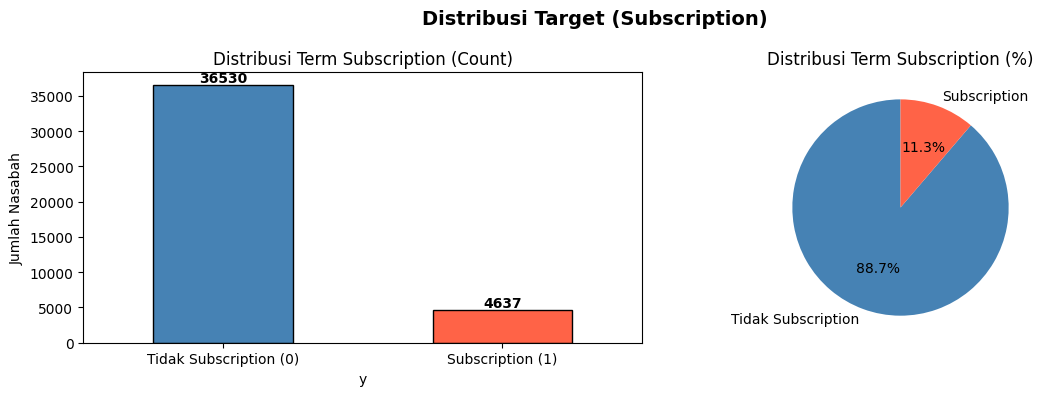

Dataset menunjukkan class imbalance (~11% subscription). Perlu ditangani saat modeling.


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['y'].value_counts().plot(kind='bar', ax=axes[0],
    color=['steelblue', 'tomato'], edgecolor='black')
axes[0].set_title('Distribusi Term Subscription (Count)')
axes[0].set_xticklabels(['Tidak Subscription (0)', 'Subscription (1)'], rotation=0)
axes[0].set_ylabel('Jumlah Nasabah')
for p in axes[0].patches:
    axes[0].annotate(str(p.get_height()),
        (p.get_x() + p.get_width()/2., p.get_height()),
        ha='center', va='bottom', fontweight='bold')

df['y'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
    labels=['Tidak Subscription', 'Subscription'], colors=['steelblue', 'tomato'], startangle=90)
axes[1].set_title('Distribusi Term Subscription (%)')
axes[1].set_ylabel('')

plt.suptitle('Distribusi Target (Subscription)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
print("Dataset menunjukkan class imbalance (~11% subscription). Perlu ditangani saat modeling.")

### 4.1.2 Distribusi Fitur Numerik

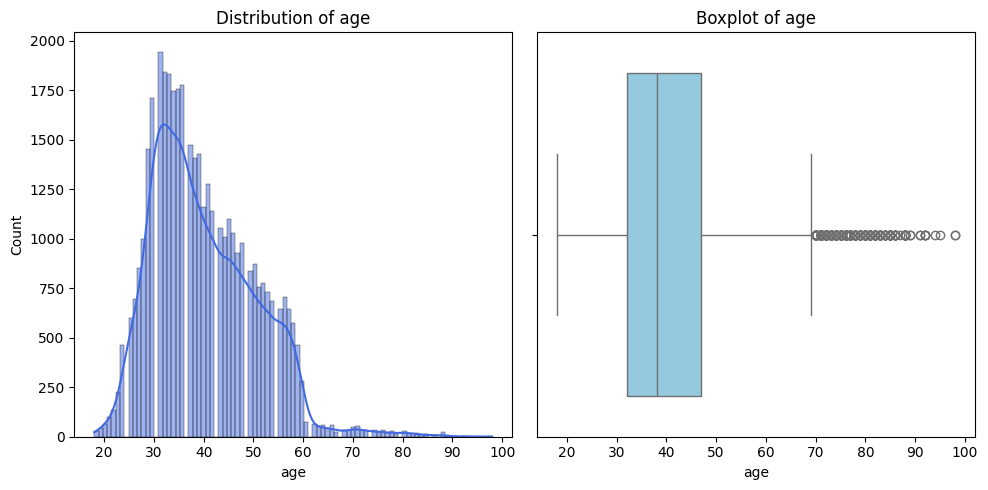


Column: age
   Mean               : 40.03
   Median             : 38.00
   Range              : 80.00
   Standard Deviation : 10.42
   Outlier (Unique)   : [np.int64(70), np.int64(76), np.int64(73), np.int64(88), np.int64(95), np.int64(77), np.int64(75), np.int64(80), np.int64(72), np.int64(82), np.int64(71), np.int64(78), np.int64(85), np.int64(79), np.int64(83), np.int64(81), np.int64(74), np.int64(87), np.int64(91), np.int64(86), np.int64(98), np.int64(94), np.int64(84), np.int64(92), np.int64(89)]


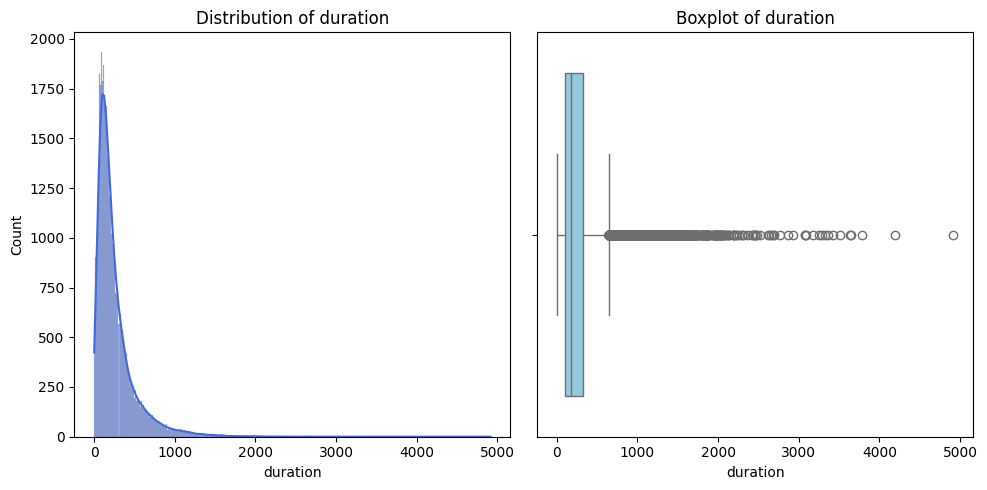


Column: duration
   Mean               : 258.32
   Median             : 180.00
   Range              : 4917.00
   Standard Deviation : 259.30
   Outlier (Unique)   : [np.int64(1666), np.int64(787), np.int64(812), np.int64(1575), np.int64(1042), np.int64(1467), np.int64(849), np.int64(677), np.int64(2033), np.int64(843), np.int64(673), np.int64(717), np.int64(683), np.int64(1077), np.int64(730), np.int64(702), np.int64(962), np.int64(935), np.int64(742), np.int64(669), np.int64(680), np.int64(1201), np.int64(1030), np.int64(769), np.int64(744), np.int64(1623), np.int64(678), np.int64(699), np.int64(1677), np.int64(918), np.int64(792), np.int64(1297), np.int64(695), np.int64(1906), np.int64(802), np.int64(739), np.int64(1597), np.int64(716), np.int64(1529), np.int64(800), np.int64(720), np.int64(852), np.int64(992), np.int64(732), np.int64(1521), np.int64(1138), np.int64(786), np.int64(799), np.int64(866), np.int64(1581), np.int64(650), np.int64(1101), np.int64(912), np.int64(1062), np.

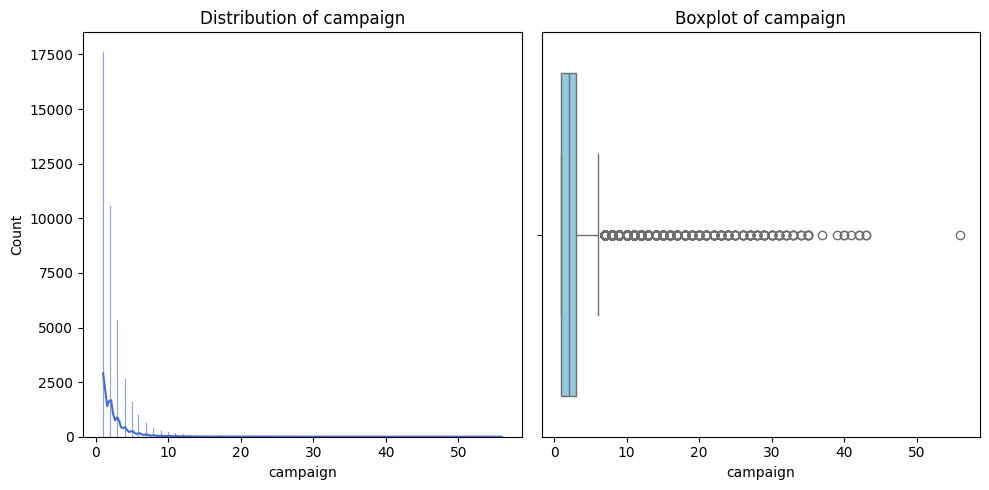


Column: campaign
   Mean               : 2.57
   Median             : 2.00
   Range              : 55.00
   Standard Deviation : 2.77
   Outlier (Unique)   : [np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(19), np.int64(18), np.int64(23), np.int64(14), np.int64(22), np.int64(25), np.int64(16), np.int64(17), np.int64(15), np.int64(20), np.int64(56), np.int64(39), np.int64(35), np.int64(42), np.int64(28), np.int64(26), np.int64(27), np.int64(32), np.int64(21), np.int64(24), np.int64(29), np.int64(31), np.int64(30), np.int64(41), np.int64(37), np.int64(40), np.int64(33), np.int64(34), np.int64(43)]


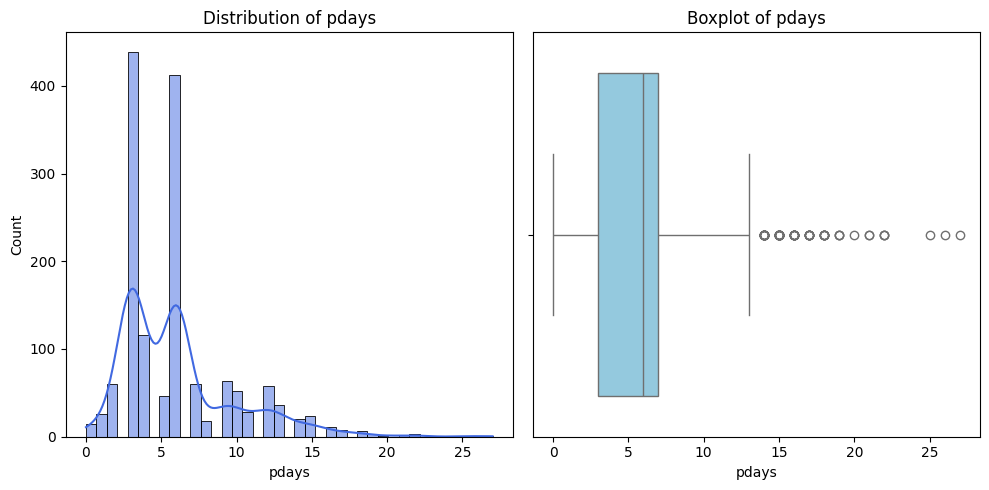


Column: pdays
   Mean               : 6.02
   Median             : 6.00
   Range              : 27.00
   Standard Deviation : 3.83
   Outlier (Unique)   : [np.float64(14.0), np.float64(15.0), np.float64(16.0), np.float64(21.0), np.float64(17.0), np.float64(18.0), np.float64(22.0), np.float64(25.0), np.float64(26.0), np.float64(19.0), np.float64(27.0), np.float64(20.0)]


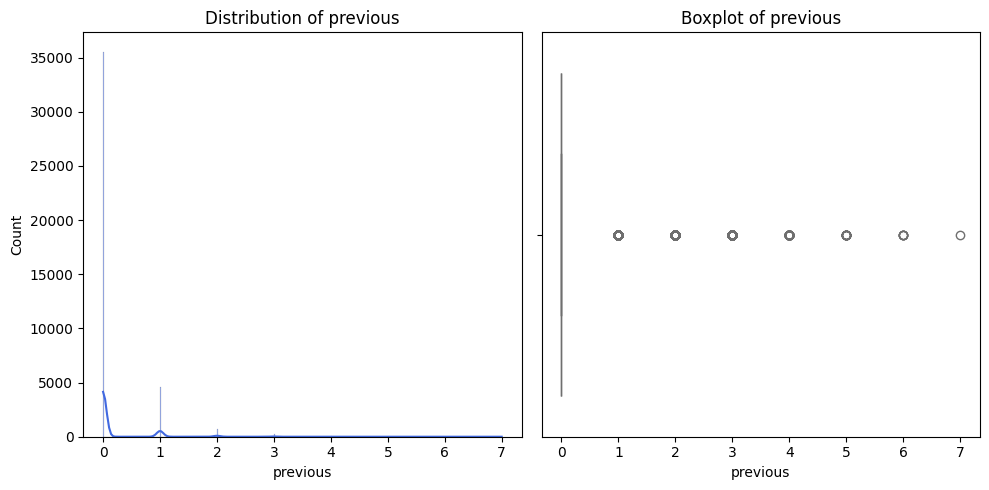


Column: previous
   Mean               : 0.17
   Median             : 0.00
   Range              : 7.00
   Standard Deviation : 0.49
   Outlier (Unique)   : [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


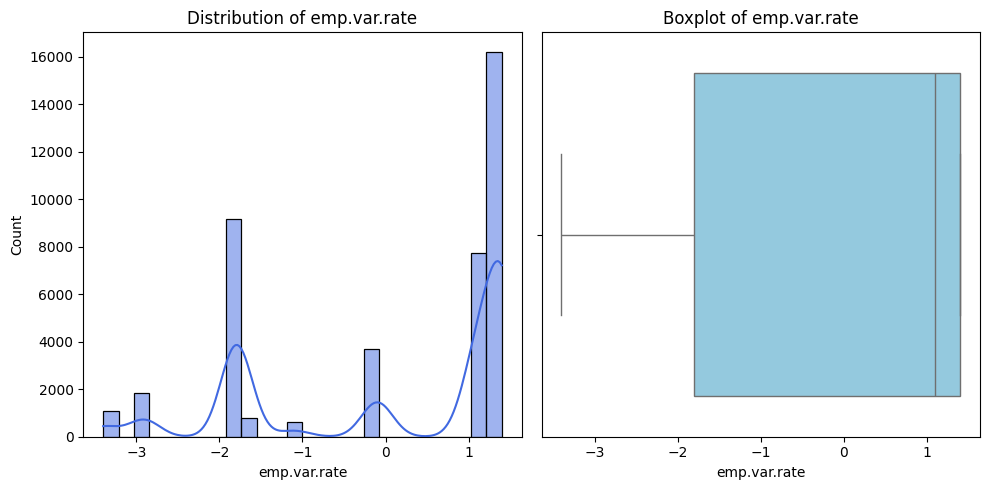


Column: emp.var.rate
   Mean               : 0.08
   Median             : 1.10
   Range              : 4.80
   Standard Deviation : 1.57
   Outlier (Unique)   : []


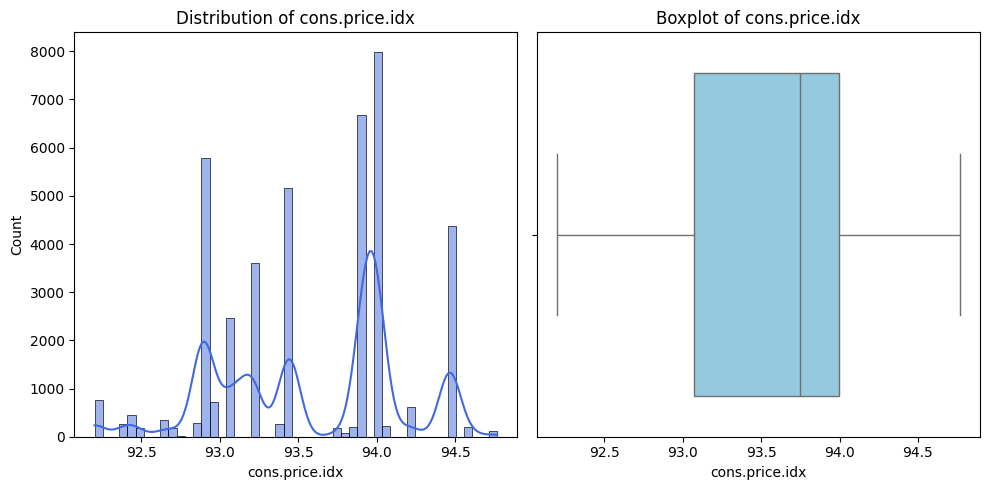


Column: cons.price.idx
   Mean               : 93.58
   Median             : 93.75
   Range              : 2.57
   Standard Deviation : 0.58
   Outlier (Unique)   : []


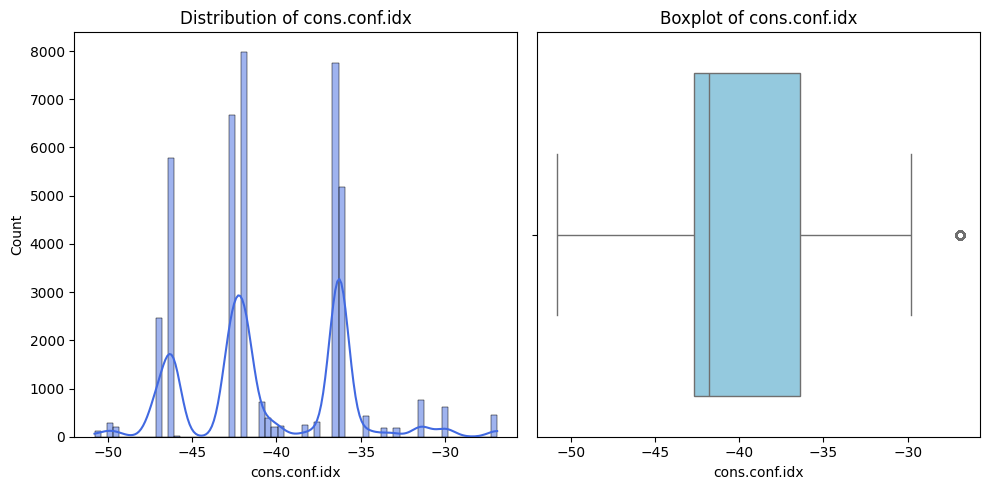


Column: cons.conf.idx
   Mean               : -40.50
   Median             : -41.80
   Range              : 23.90
   Standard Deviation : 4.63
   Outlier (Unique)   : [np.float64(-26.9)]


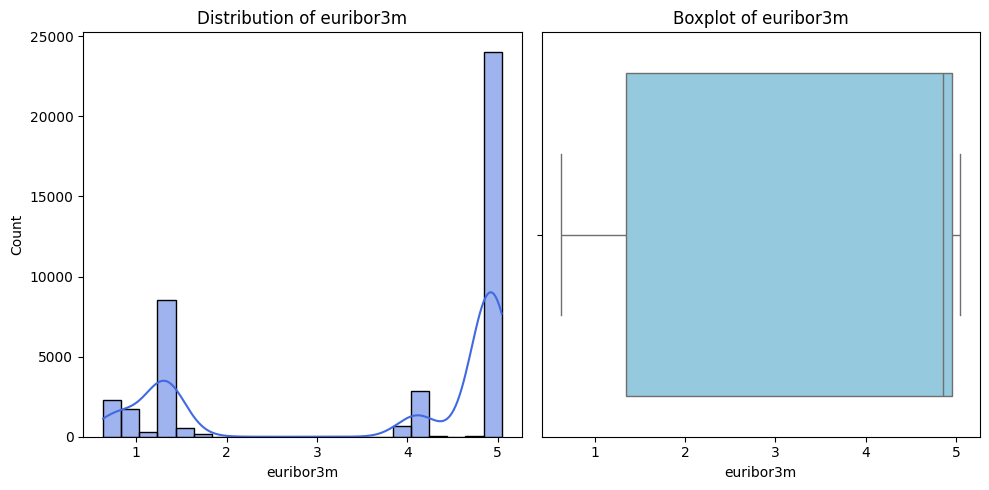


Column: euribor3m
   Mean               : 3.62
   Median             : 4.86
   Range              : 4.41
   Standard Deviation : 1.73
   Outlier (Unique)   : []


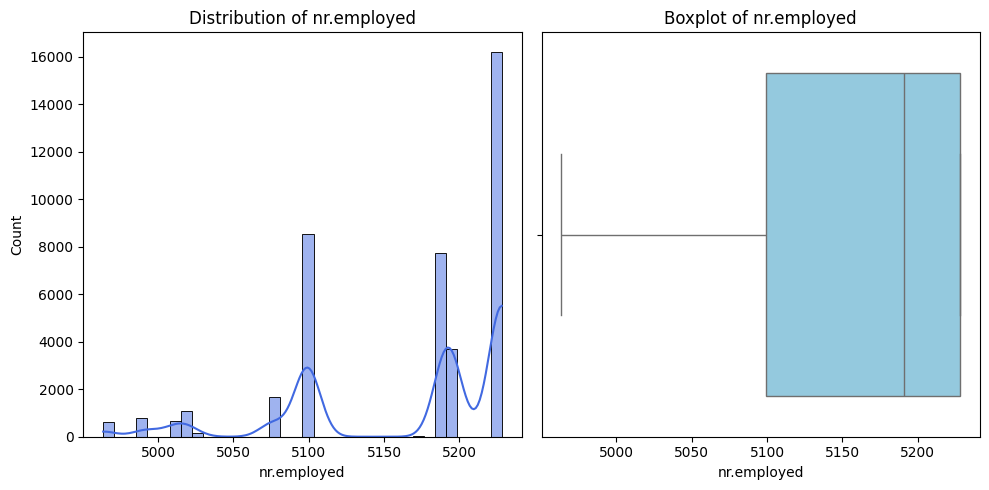


Column: nr.employed
   Mean               : 5167.05
   Median             : 5191.00
   Range              : 264.50
   Standard Deviation : 72.25
   Outlier (Unique)   : []


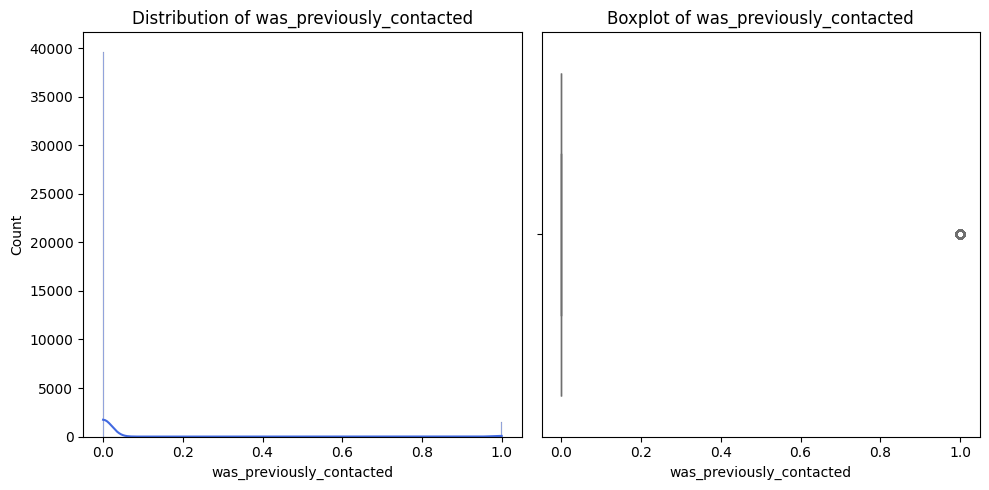


Column: was_previously_contacted
   Mean               : 0.04
   Median             : 0.00
   Range              : 1.00
   Standard Deviation : 0.19
   Outlier (Unique)   : [np.int64(1)]


In [17]:
# Mengabaikan target
numeric_cols = df.drop(['y'], axis=1, errors='ignore').select_dtypes(include='number').columns
numeric_features = [c for c in numeric_cols if c != 'y']

for col in numeric_cols:
    plt.figure(figsize=(10, 5))

    # Plot 1: Histogram (Distribusi Data)
    plt.subplot(1, 2, 1)
    sns.histplot(data=df, x=col, kde=True, color='royalblue')
    plt.title(f"Distribution of {col}")
    plt.grid(False)

    # Plot 2: Boxplot (Deteksi Outlier)
    plt.subplot(1, 2, 2)
    sns.boxplot(data=df, x=col, color='skyblue')
    plt.title(f"Boxplot of {col}")
    plt.grid(False)

    plt.tight_layout()
    plt.show()

    # Statistik Deskriptif
    print(f"\nColumn: {col}")
    print(f"   Mean               : {df[col].mean():.2f}")
    print(f"   Median             : {df[col].median():.2f}")
    print(f"   Range              : {df[col].max() - df[col].min():.2f}")
    print(f"   Standard Deviation : {df[col].std():.2f}")

    # Perhitungan Batas Outlier (IQR)
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lowerwhisker = Q1 - 1.5 * IQR
    upperwhisker = Q3 + 1.5 * IQR

    # Mengambil nilai unik outlier agar ringkas saat di-print
    outlier = list(df[(df[col] < lowerwhisker) | (df[col] > upperwhisker)][col].unique())
    print(f"   Outlier (Unique)   : {outlier}")

    print("  " + "="*50)

**Ringkasan Analisis Univariate (Kolom Numerik)**

- Variabel age terkonsentrasi pada kelompok usia produktif (25–45 tahun), dengan median 35. Sebagian kecil populasi berusia lanjut (> 70) muncul sebagai outlier. Variabel tersebut mengalami right-skewed dimana jumlah menurun perlahan hingga mendekati usia 100 tahun. Sementara variabel duration sebagian besar panggilan dalam durasi relatif singkat ( < 1000 detik), tetapi terdapat sejumlah panggilan dengan durasi sangat panjang hingga sekitar 5000 detik, menunjukkan adanya durasi kontak yang tinggi.

- Variabel campaign terdapat sebagian besar nasabah hanya memiliki sedikit jumlah campaign (1–2 kali), sementara campaign yang lebih tinggi jarang terjadi dan muncul sebagai outlier.Sebagian besar data pdays terkonsentrasi pada nilai rendah (sekitar 5–7), dengan sedikit kasus ekstrem di atas 15. Hal ini menunjukkan mayoritas nasabah dihubungi kembali dalam waktu relatif singkat, sementara sebagian kecil mengalami jeda kontak yang jauh lebih lama. Variabel previous hampir semua bernilai 0 (tidak ada kontak sebelumnya). Nilai outlier sebesar 1-7 menunjukkan sebagian besar nasabah baru pertama kali dihubungi.

- Variabel ekonomi (emp.var.rate, cons.price.idx, cons.conf.idx, euribor3m, nr.employed) menggambarkan kondisi makro: harga relatif stabil, kepercayaan konsumen rendah, suku bunga bervariasi, tenaga kerja tinggi.

### 4.1.3 Distribusi Fitur Kategorikal

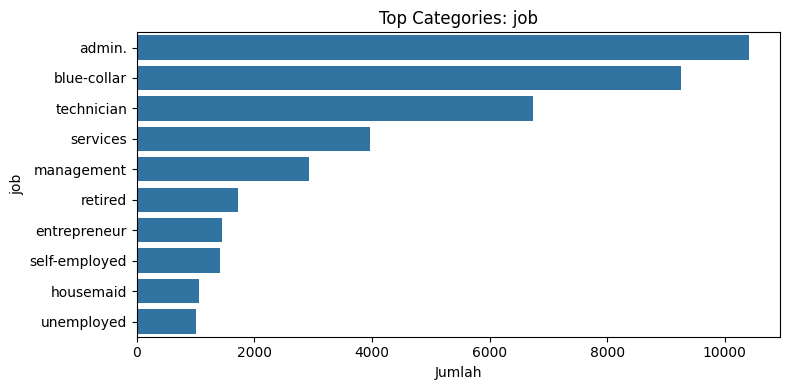

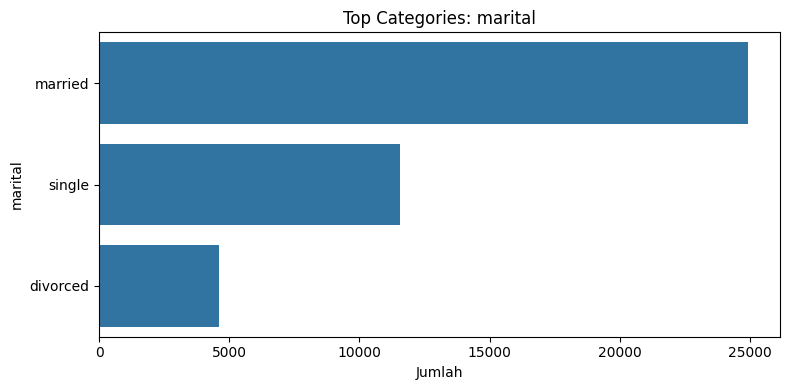

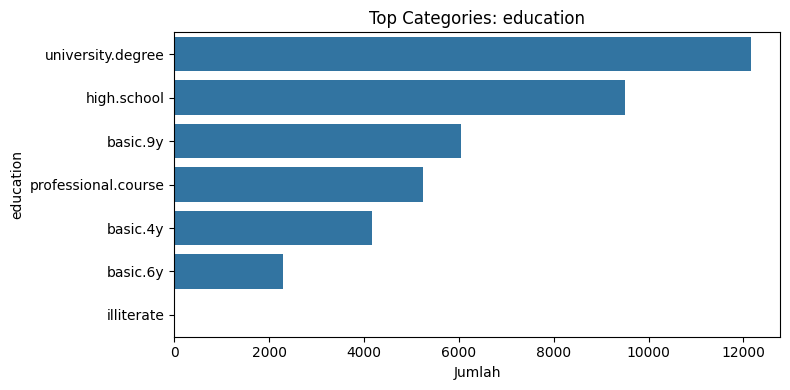

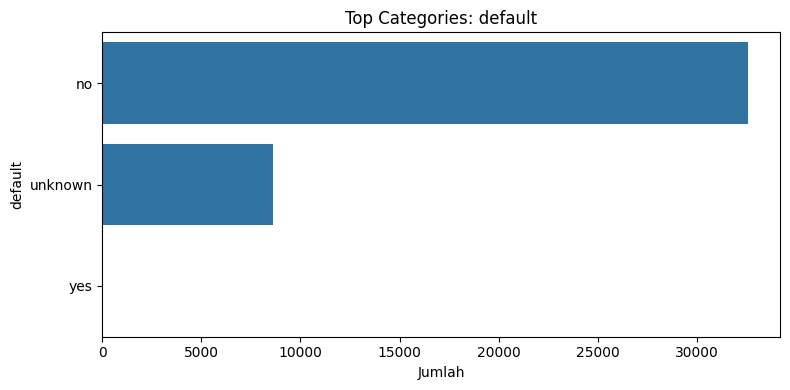

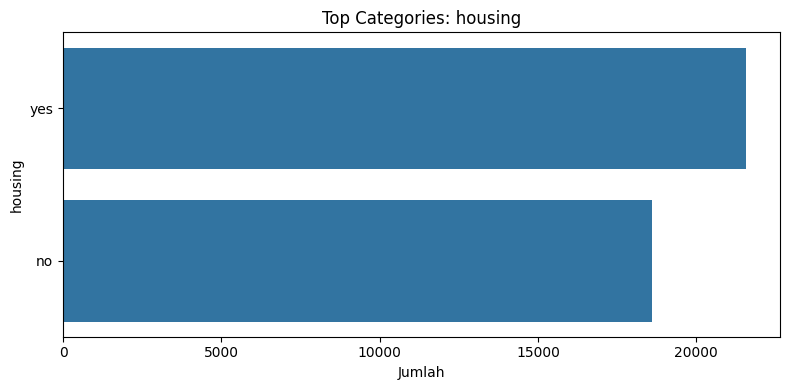

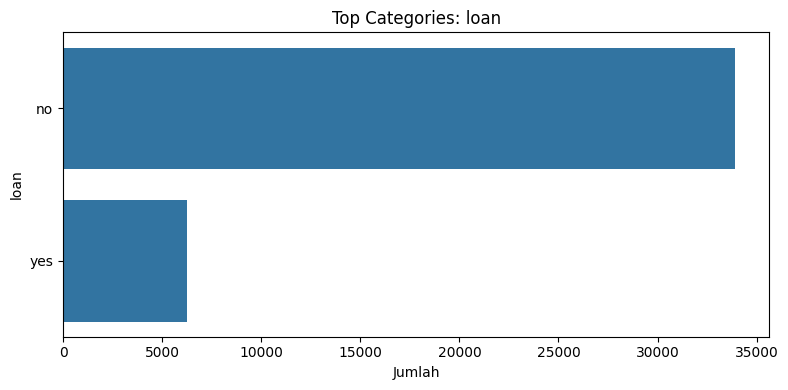

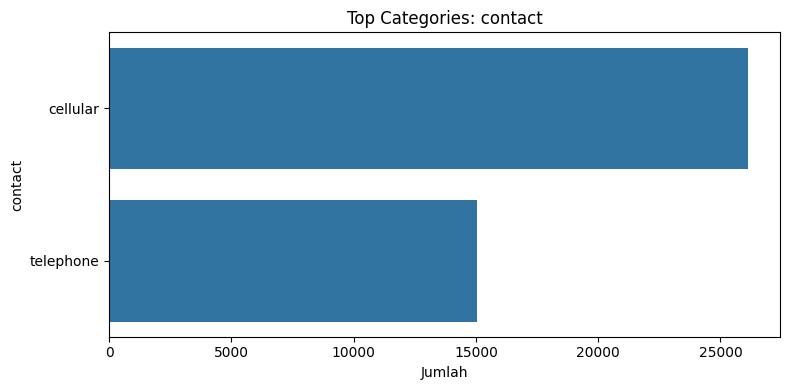

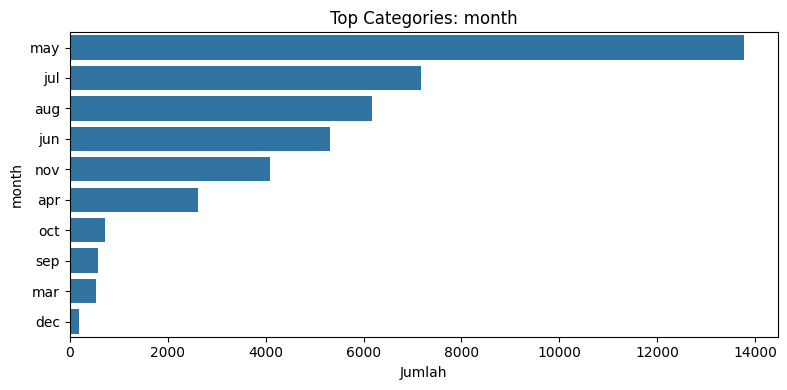

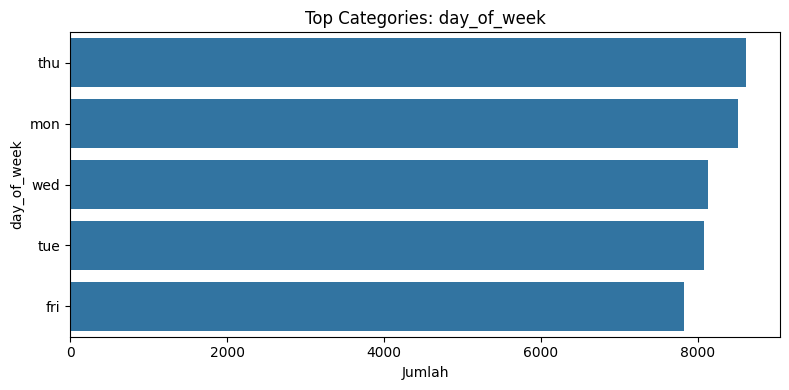

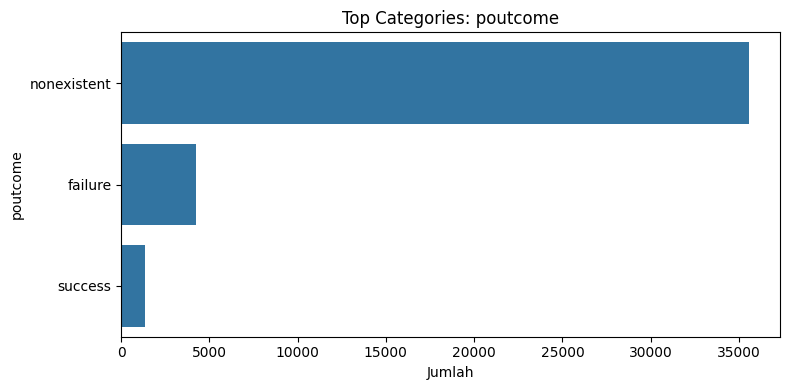

In [18]:
categorical_features = [c for c in cat_cols if c != "y"]

for col in categorical_features:
    counts = df[col].value_counts().head(10)
    plt.figure(figsize=(8, 4))
    sns.barplot(x=counts.values, y=counts.index)
    plt.title(f"Top Categories: {col}")
    plt.xlabel("Jumlah")
    plt.ylabel(col)
    plt.tight_layout()
    plt.show()

**Ringkasan Analisis Univariate (Kolom Kategori)**

- Demografi → Mayoritas nasabah berpendidikan tinggi yang menunjukkan literasi finansial yang cukup baik. Selain itu, didominasi oleh nasabah yang bekerja sebagai admin, blue-collar, technician sehingga menunjukkan basis tenaga kerja besar di sektor administratif, serta masabah sudah menikah mengindikasikan tingkat stabilitas domestik yang relatif tinggi.

- Keuangan → Sebagian besar tidak memiliki riwayat kredit macet, banyak yang punya kredit rumah, tapi sedikit yang punya pinjaman pribadi.

- Campaign → Lebih sering dilakukan via ponsel, paling aktif di bulan Mei dan hari Kamis.

- Outcome → Tingkat keberhasilan campaign masih rendah, mayoritas nasabah belum pernah ikut campaign sebelumnya.

## **4.2 Bivariate Analysis**

### 4.2.1 Numerical vs Subscription

In [19]:
subscription_group = df.groupby("y")[numeric_cols].mean().T
subscription_group.columns = ["no", "yes"]
print("Rata-rata Fitur Numerik per Kelas Subscription:")
print(subscription_group.round(2))

Rata-rata Fitur Numerik per Kelas Subscription:
                               no      yes
age                         39.91    40.92
duration                   220.89   553.19
campaign                     2.63     2.05
pdays                        6.20     5.92
previous                     0.13     0.49
emp.var.rate                 0.25    -1.23
cons.price.idx              93.60    93.36
cons.conf.idx              -40.59   -39.80
euribor3m                    3.81     2.12
nr.employed               5176.18  5095.14
was_previously_contacted     0.01     0.21



--- Bivariate Analysis: Boxplot vs 5-Bin Default Rate ---


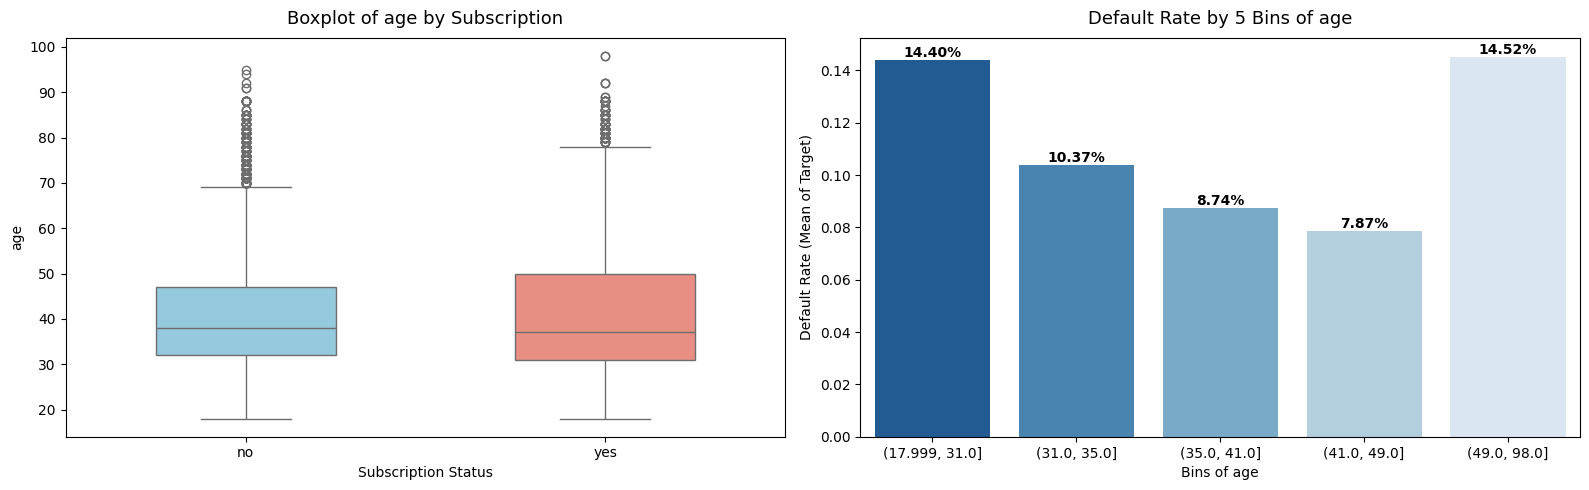

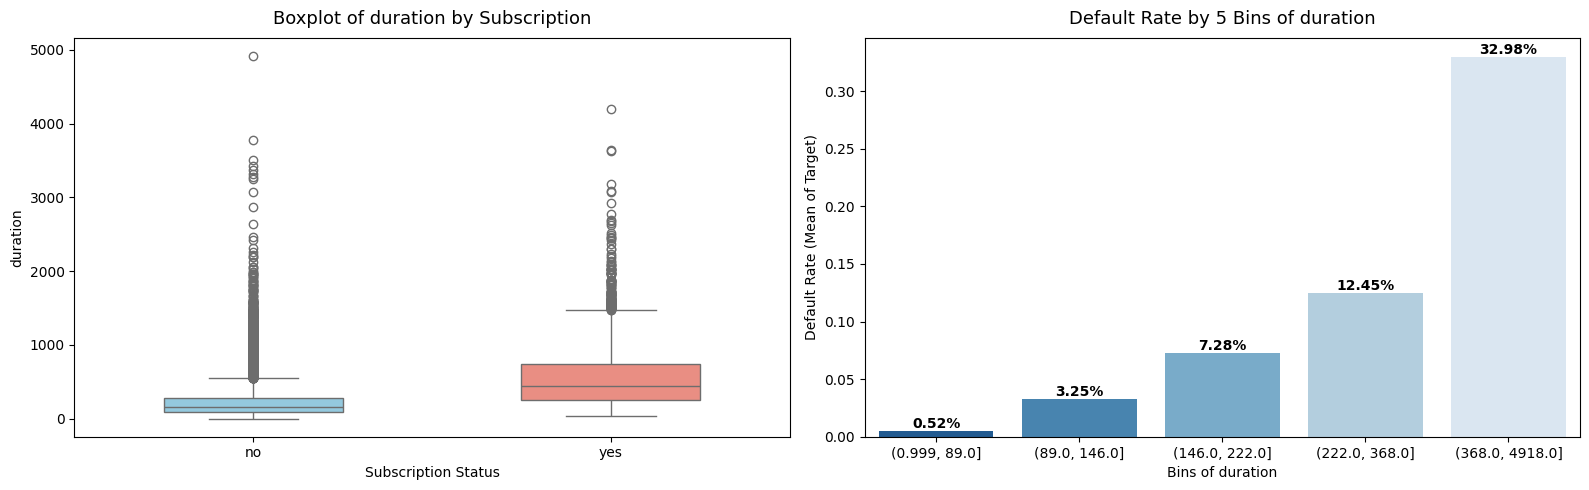

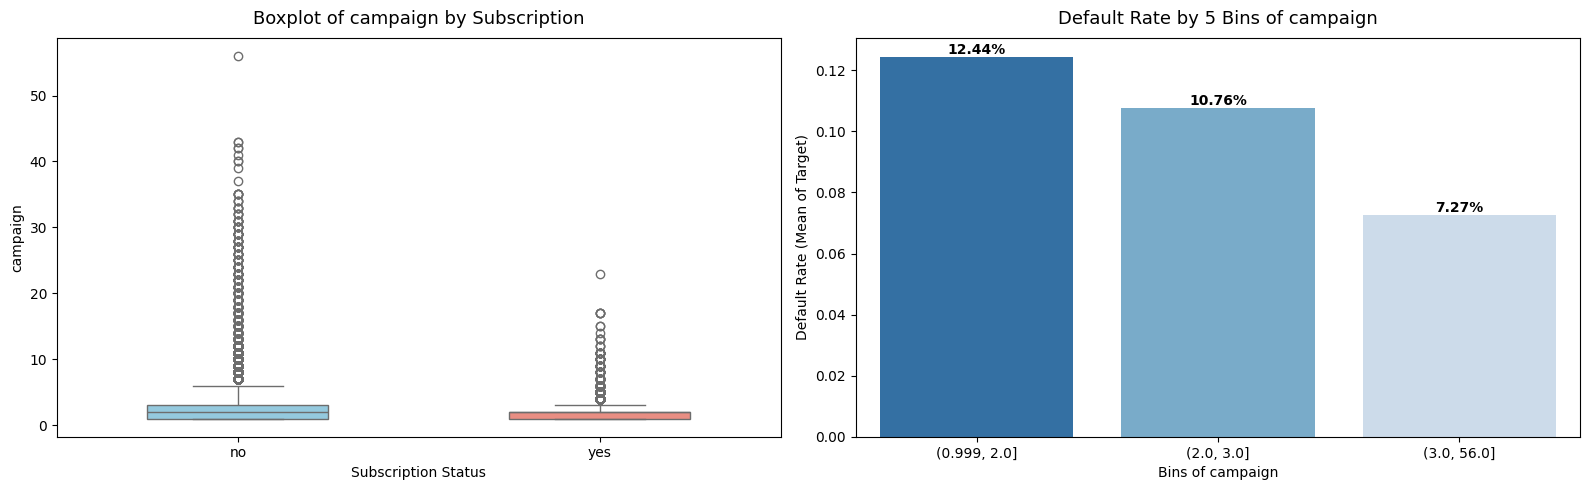

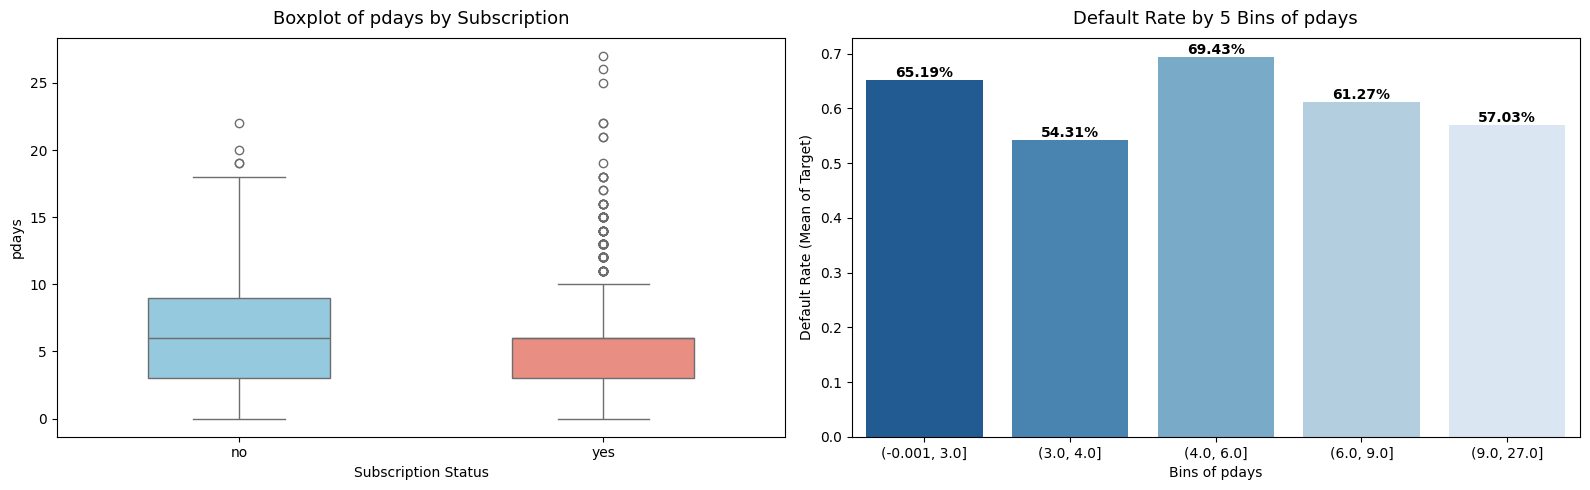

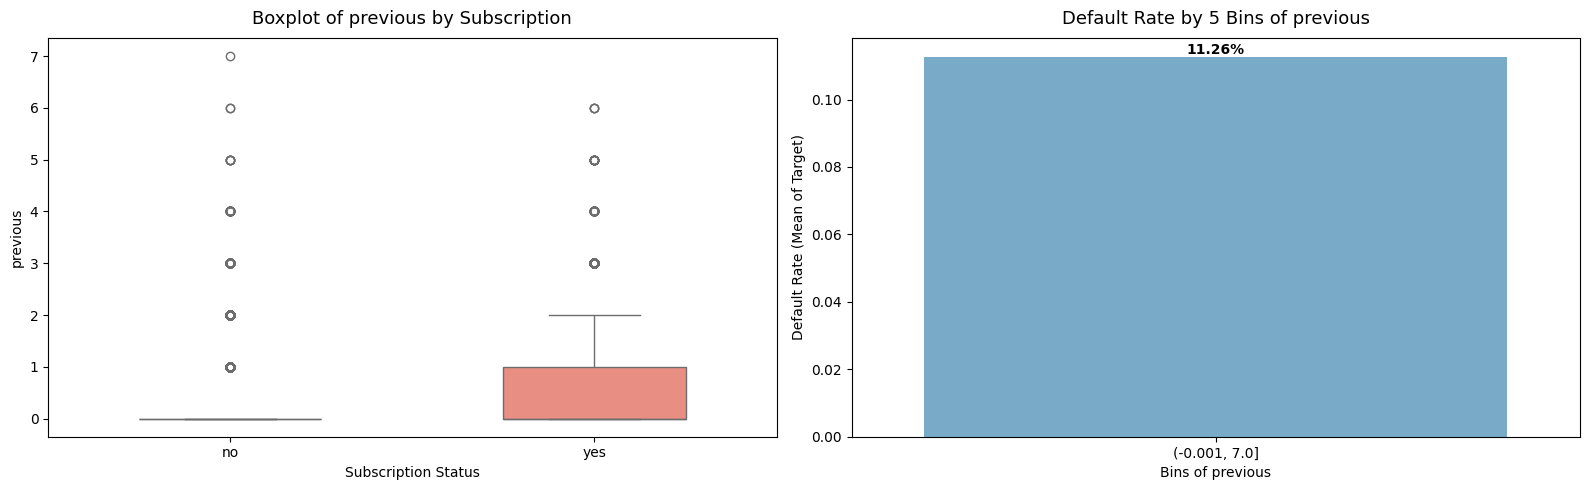

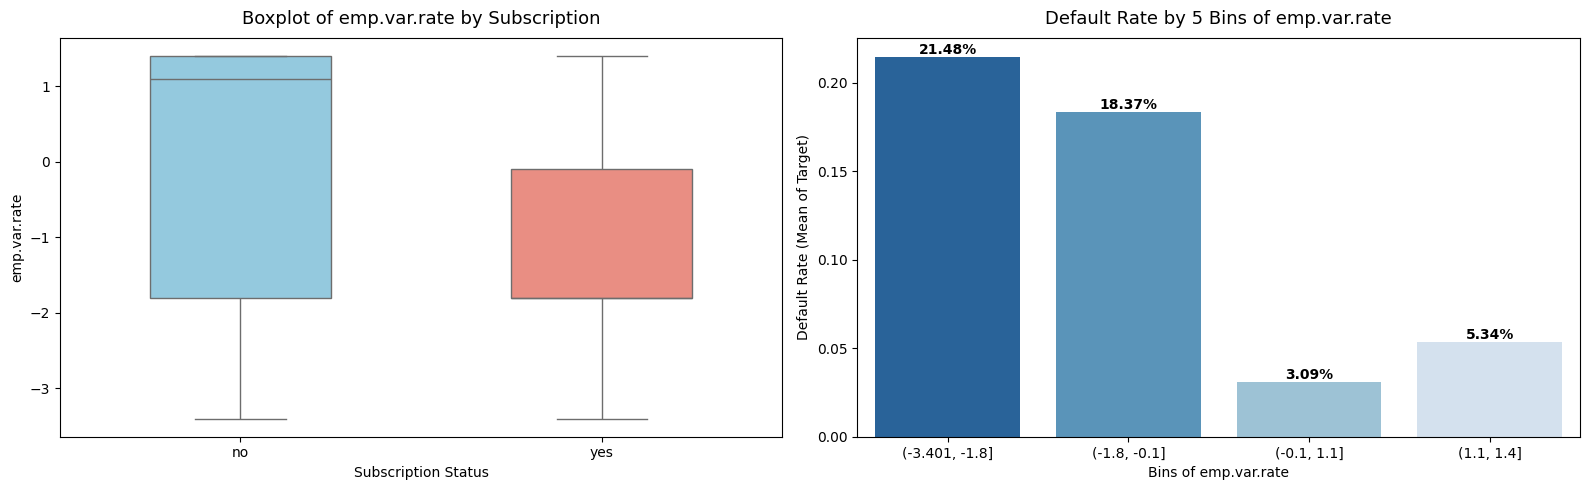

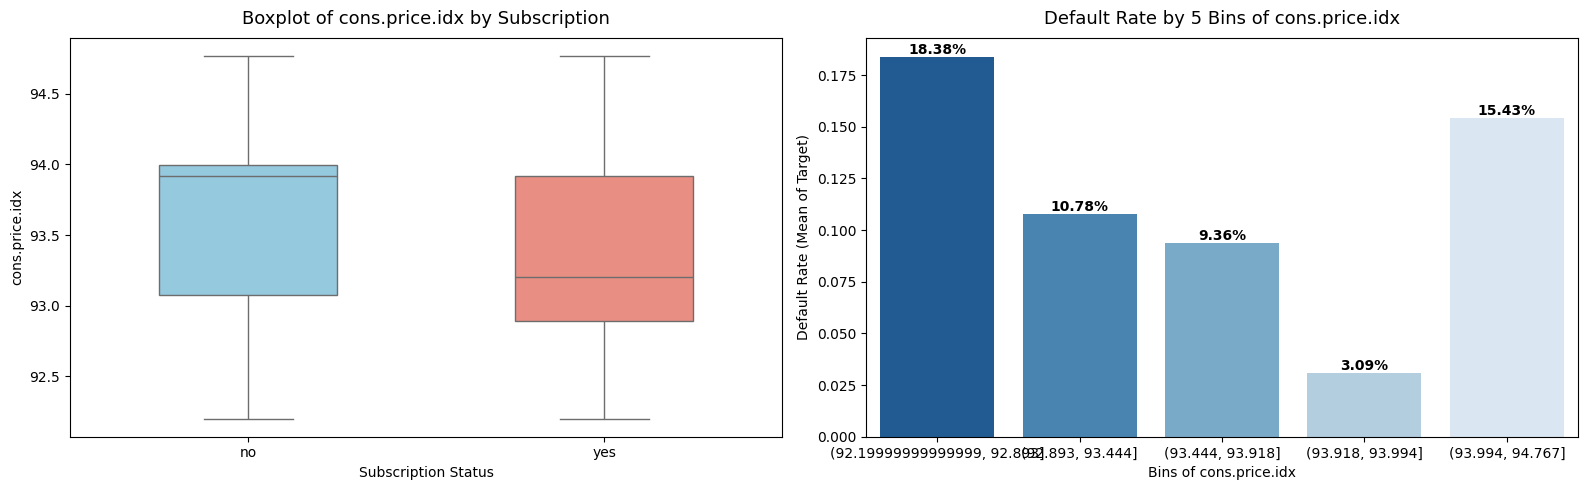

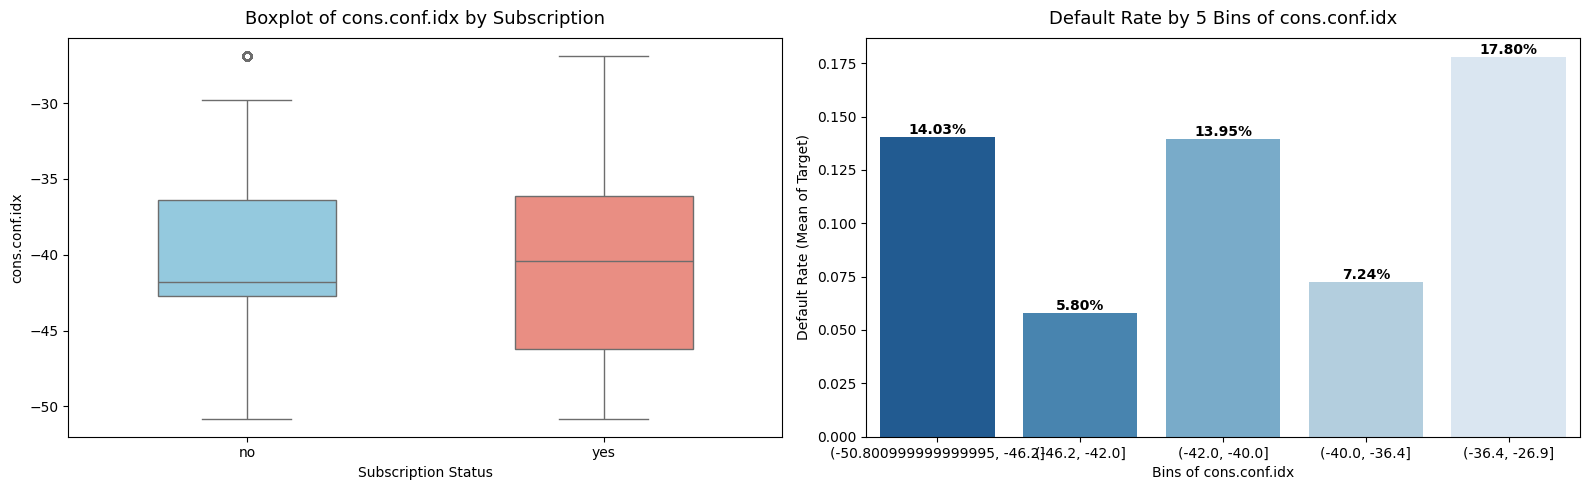

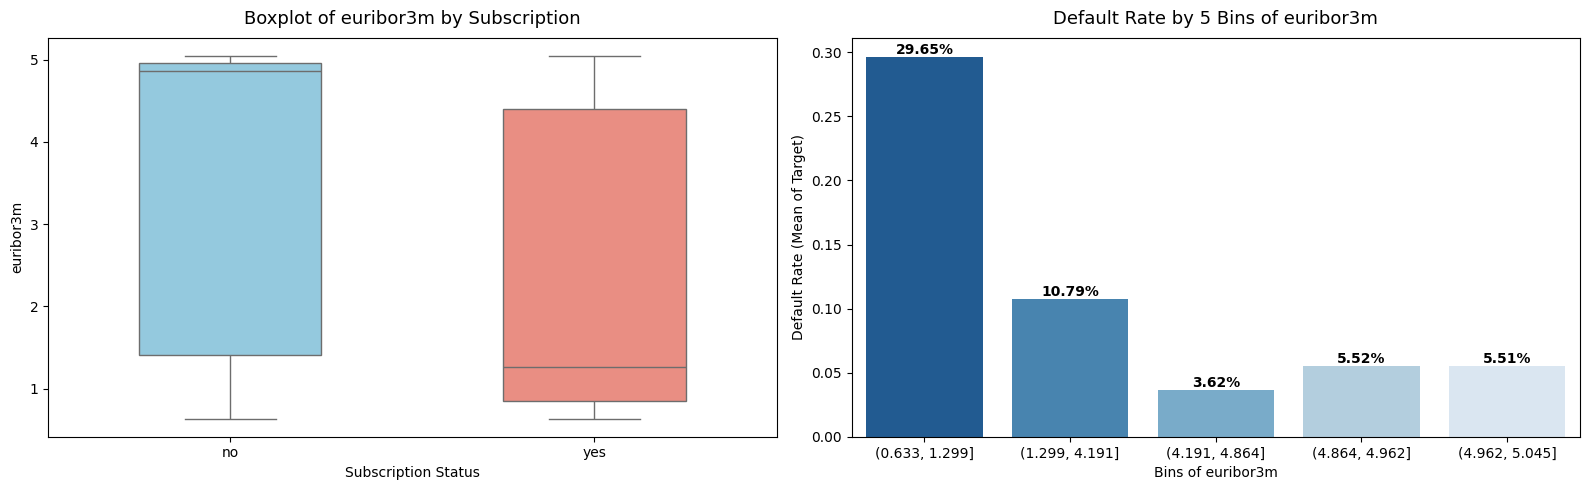

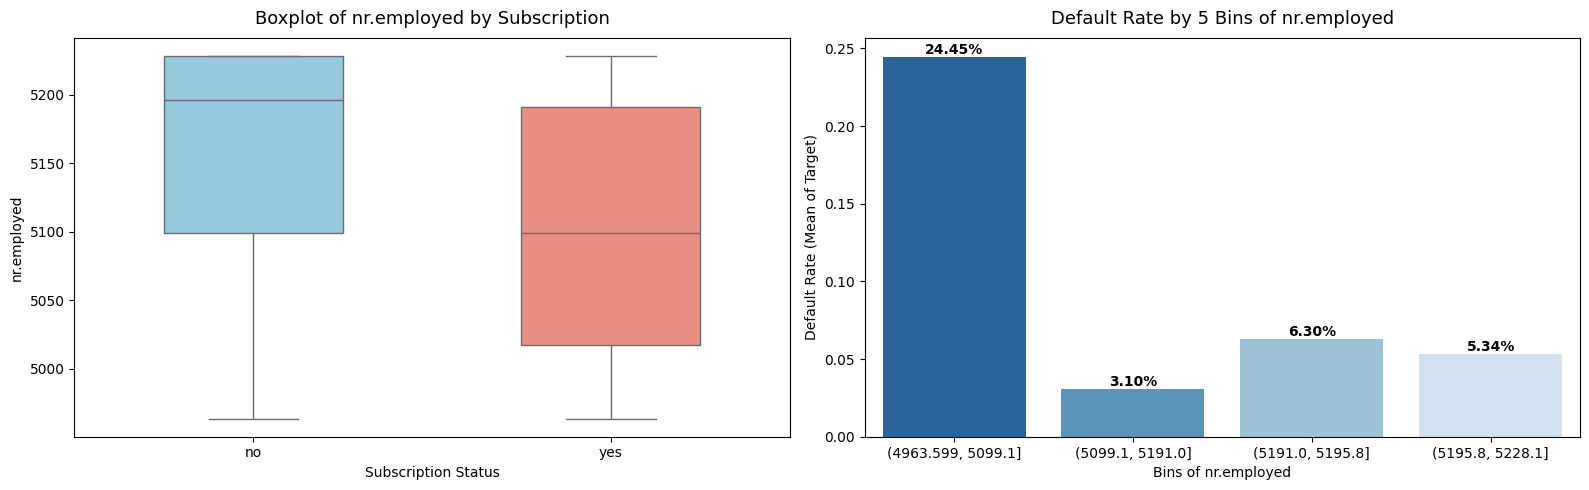

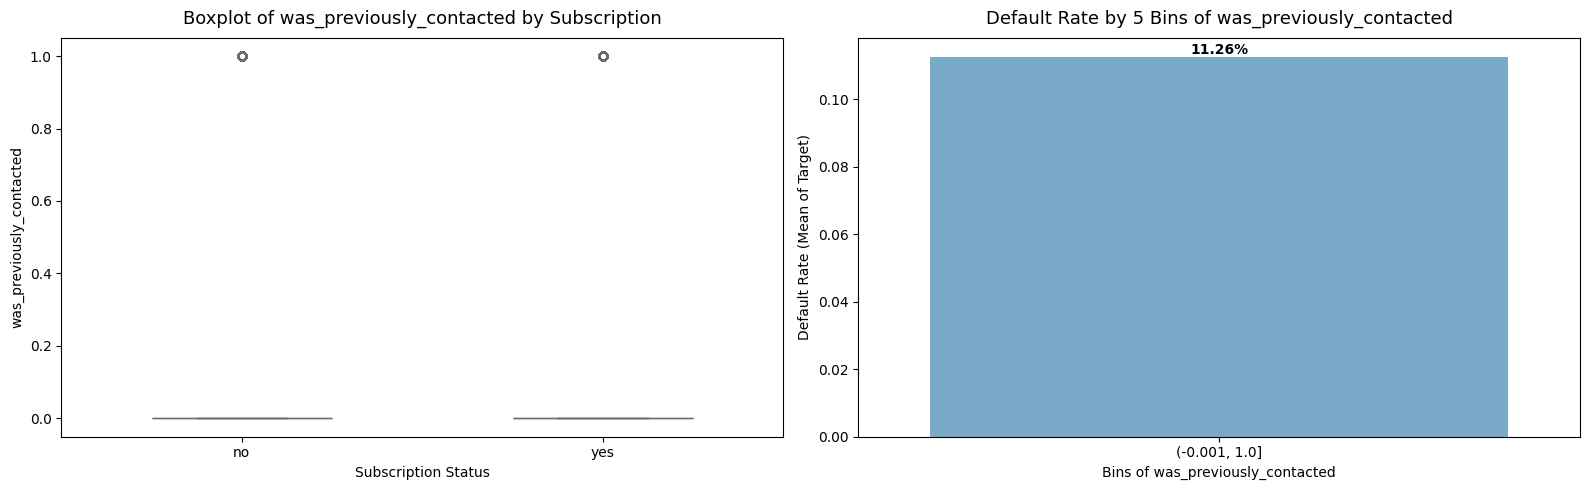

In [20]:
# Ambil kolom numerik (mengabaikan target dan ID)
numeric_cols = df.drop(['y'], axis=1, errors='ignore').select_dtypes(include='number').columns

print("\n--- Bivariate Analysis: Boxplot vs 5-Bin Default Rate ---")

for col in numeric_cols:
    fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))

    # Palette warna kustom untuk Boxplot (Target dipaksa String)
    custom_palette = {'no': "skyblue", 'yes': "salmon"}

    # --------------------------------------------------------
    # PLOT 1: Boxplot (Kiri)
    # --------------------------------------------------------
    sns.boxplot(data=df, x=df['y'].astype(str), y=df[col],
                palette=custom_palette, ax=axes[0], width=0.5)
    axes[0].set_title(f"Boxplot of {col} by Subscription", fontsize=13, pad=10)
    axes[0].set_xlabel("Subscription Status")
    axes[0].set_ylabel(col)
    axes[0].grid(False)

    # --------------------------------------------------------
    # PLOT 2: Default Rate by 5 Bins (Kanan)
    # --------------------------------------------------------
    df_temp = df[[col, 'y']].copy()
    df_temp['y'] = df_temp['y'].map({'no': 0, 'yes': 1})

    # Buat kolom bin
    try:
        df_temp['bin'] = pd.qcut(df_temp[col], q=5, duplicates='drop')
    except ValueError:
        df_temp['bin'] = pd.cut(df_temp[col], bins=5)

    # Hitung default rate per bin
    df_bin_agg = df_temp.groupby('bin')['y'].mean().reset_index()
    df_bin_agg.columns = ['Bin Group', 'Default Rate']

    # Barplot default rate
    sns.barplot(data=df_bin_agg, x='Bin Group', y='Default Rate',
                palette='Blues_r', ax=axes[1])

    # Tampilkan angka persentase di atas setiap bar
    for p in axes[1].patches:
        axes[1].annotate(f"{p.get_height()*100:.2f}%",
                         (p.get_x() + p.get_width() / 2., p.get_height()),
                         ha='center', va='center',
                         xytext=(0, 5),
                         textcoords='offset points',
                         fontsize=10, weight='bold')

    axes[1].set_title(f"Default Rate by 5 Bins of {col}", fontsize=13, pad=10)
    axes[1].set_xlabel(f"Bins of {col}")
    axes[1].set_ylabel("Default Rate (Mean of Target)")

    plt.tight_layout()
    plt.show()

**Ringkasan Analisis Bivariate (Numerik vs Subscription)**

**Demografi & Perilaku Nasabah**

- Age → Tingkat subscription tertinggi ada di kelompok usia muda (<31 tahun, 14.40%) dan usia lanjut (>49 tahun, 14.52%). Kelompok usia tengah (31–49 tahun) memiliki default rate lebih rendah (7–10%).Artinya, nasabah muda dan lansia lebih responsif terhadap campaign dibanding usia produktif menengah.

- Duration (lama kontak) → Semakin lama durasi kontak, semakin tinggi default rate. Dari 0.52% (durasi <90 detik) naik drastis hingga 32.98% (durasi >368 detik). Durasi percakapan panjang berkorelasi positif dengan keberhasilan subscription.

- Campaign (jumlah kontak) → Default rate tertinggi pada kontak pertama (12.44%), menurun pada kontak berulang (7.27% untuk >3 kali). Kontak pertama paling menentukan, kontak berulang kurang efektif.

- Pdays (hari sejak kontak terakhir) → Default rate relatif tinggi di semua bin (54–69%), dengan variasi kecil. Follow-up cepat maupun lambat tetap menghasilkan tingkat subscription yang signifikan, meski tidak konsisten.

- Previous (jumlah kontak sebelumnya) → Default rate rata-rata 11.26%. Nasabah yang pernah dihubungi sebelumnya memiliki peluang subscription lebih tinggi dibanding yang belum.

**Faktor Ekonomi Makro**

- Emp.var.rate (employment variation rate) → Default rate tinggi saat kondisi ekonomi negatif (-3.4 hingga -1.8 → 21.48%), jauh lebih rendah saat kondisi positif (sekitar 1 → 3–5%). Subscription lebih berhasil saat kondisi ekonomi stabil/positif.

- Cons.price.idx (consumer price index) → Default rate bervariasi: tertinggi di rentang rendah (92.2–92.8 → 18.38%), terendah di 93.9–94.0 (3.09%). Subscription lebih berhasil saat harga konsumen relatif stabil.

- Cons.conf.idx (consumer confidence index) → Default rate tertinggi di -36.4 hingga -26.9 (17.80%), terendah di -46.2 hingga -42.0 (5.80%). Subscription lebih berhasil saat kepercayaan konsumen relatif lebih baik.

- Euribor3m (suku bunga 3 bulan) → Default rate sangat tinggi saat suku bunga rendah (0.6–1.3 → 29.65%), jauh lebih rendah saat suku bunga tinggi (4.1–5.0 → 3–5%). Subscription lebih berhasil saat suku bunga tinggi.

- Nr.employed (jumlah tenaga kerja) → Default rate tinggi saat tenaga kerja rendah (24.45% di <5100), jauh lebih rendah saat tenaga kerja tinggi (3–6%). Subscription lebih berhasil saat kondisi ketenagakerjaan kuat.

### 4.2.2 Kategorikal vs Subscription


Column: job


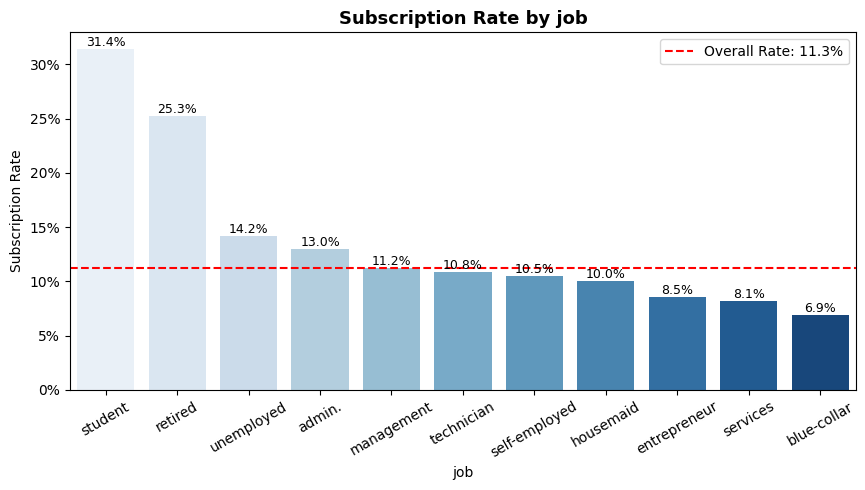

,job,subscription_rate,target
8,student,0.313793,31.4%
5,retired,0.252619,25.3%
10,unemployed,0.142012,14.2%
0,admin.,0.129679,13.0%
4,management,0.112213,11.2%
9,technician,0.108325,10.8%
6,self-employed,0.104856,10.5%
3,housemaid,0.100000,10.0%
2,entrepreneur,0.085165,8.5%
7,services,0.081422,8.1%



Column: marital


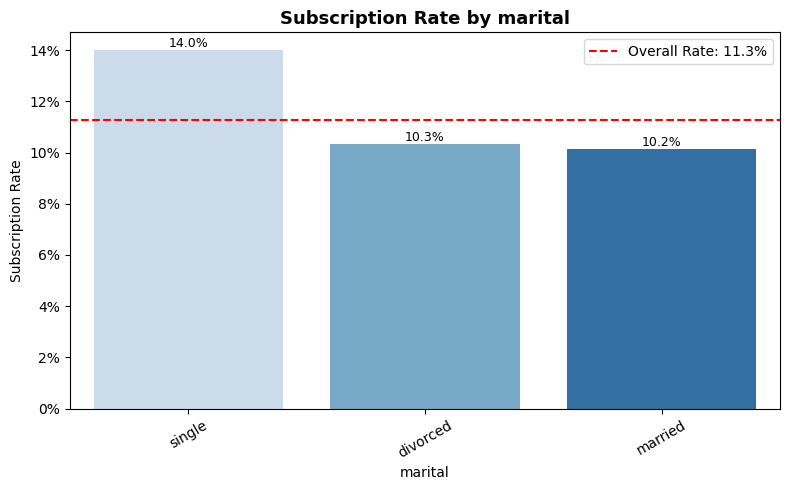

,marital,subscription_rate,target
2,single,0.139978,14.0%
0,divorced,0.103254,10.3%
1,married,0.101573,10.2%



Column: education


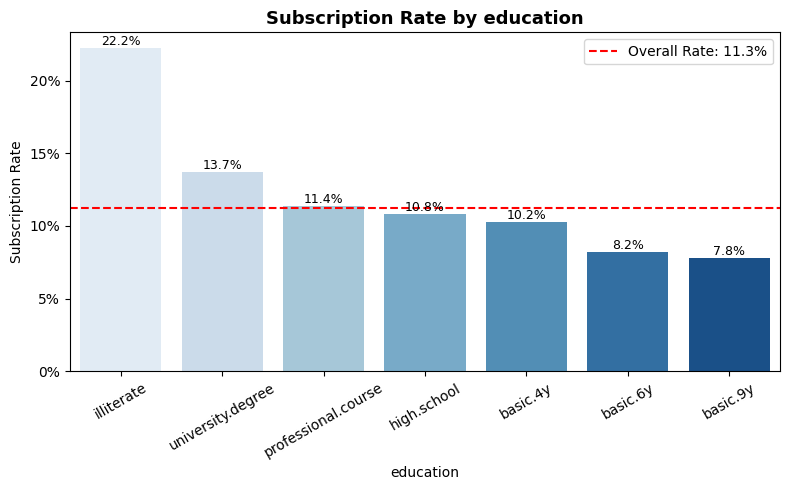

,education,subscription_rate,target
4,illiterate,0.222222,22.2%
6,university.degree,0.137219,13.7%
5,professional.course,0.113550,11.4%
3,high.school,0.108412,10.8%
0,basic.4y,0.102490,10.2%
1,basic.6y,0.082060,8.2%
2,basic.9y,0.078133,7.8%



Column: default


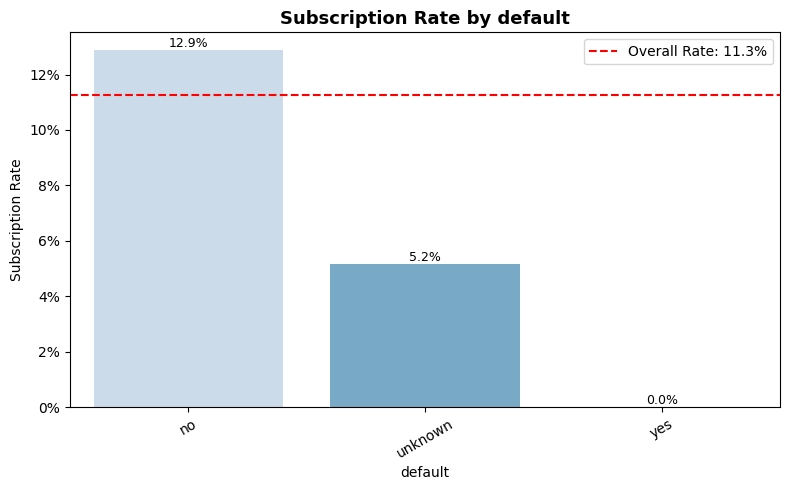

,default,subscription_rate,target
0,no,0.128777,12.9%
1,unknown,0.051536,5.2%
2,yes,0.000000,0.0%



Column: housing


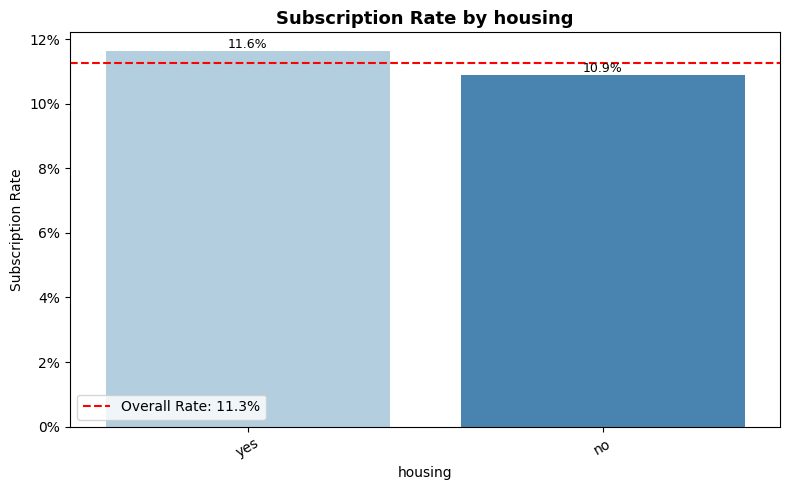

,housing,subscription_rate,target
1,yes,0.116253,11.6%
0,no,0.108741,10.9%



Column: loan


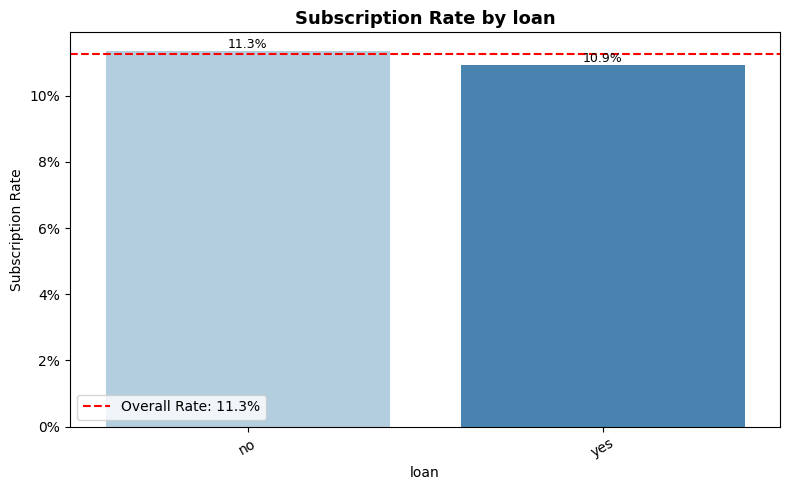

,loan,subscription_rate,target
0,no,0.113436,11.3%
1,yes,0.109172,10.9%



Column: contact


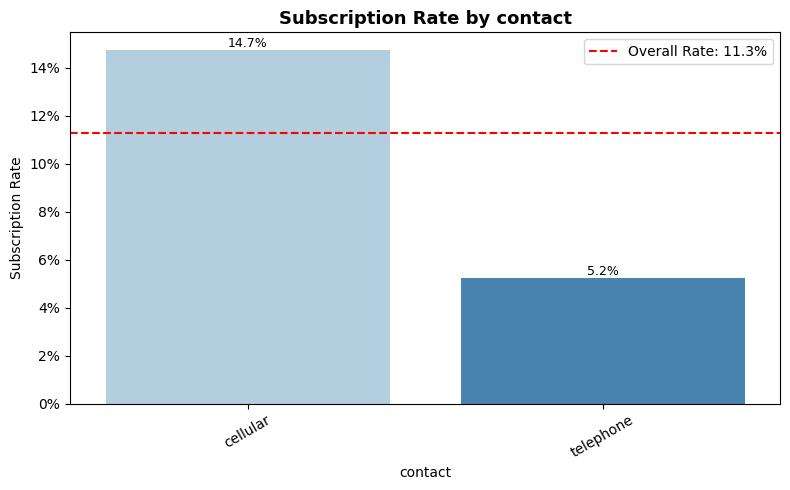

,contact,subscription_rate,target
0,cellular,0.147357,14.7%
1,telephone,0.052327,5.2%



Column: month


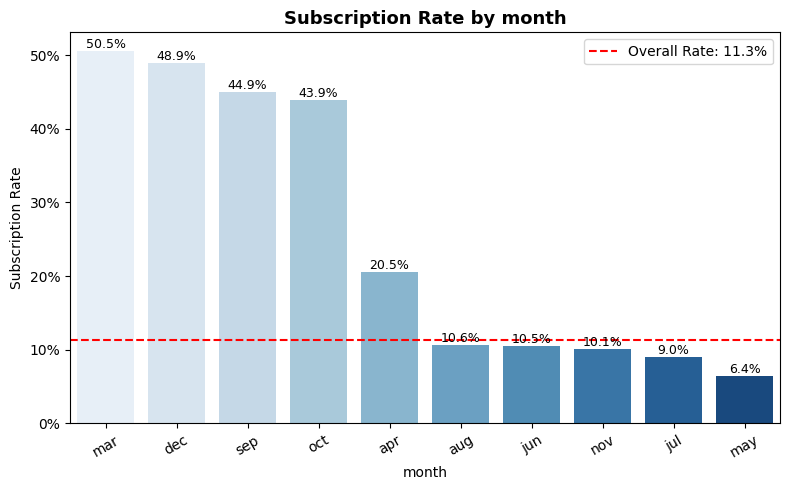

,month,subscription_rate,target
5,mar,0.505495,50.5%
2,dec,0.489011,48.9%
9,sep,0.449123,44.9%
8,oct,0.438547,43.9%
0,apr,0.204943,20.5%
1,aug,0.105980,10.6%
4,jun,0.105115,10.5%
7,nov,0.101463,10.1%
3,jul,0.090389,9.0%
6,may,0.064366,6.4%



Column: day_of_week


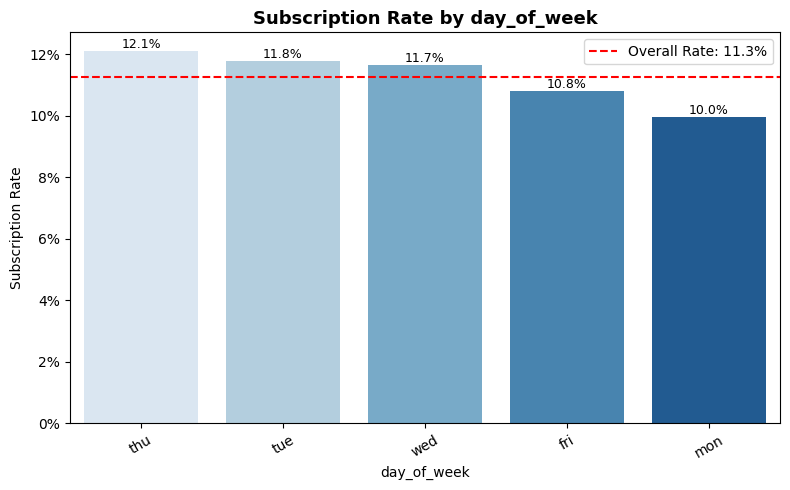

,day_of_week,subscription_rate,target
2,thu,0.121142,12.1%
3,tue,0.117778,11.8%
4,wed,0.116685,11.7%
0,fri,0.108029,10.8%
1,mon,0.099518,10.0%



Column: poutcome


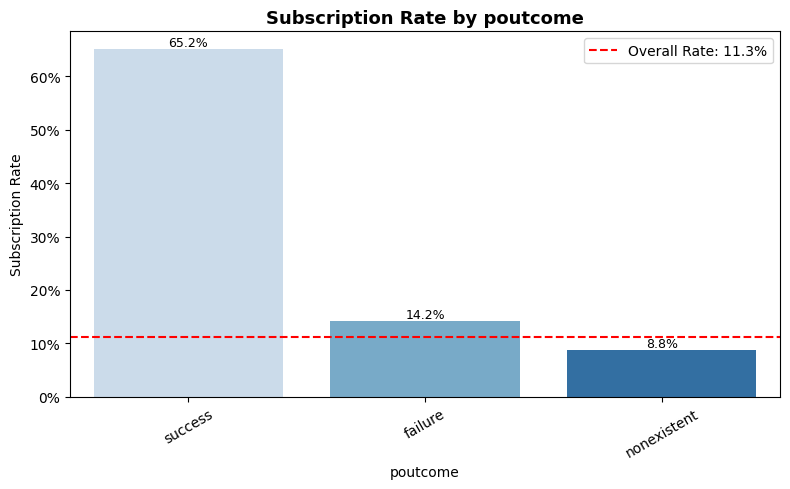

,poutcome,subscription_rate,target
2,success,0.651825,65.2%
0,failure,0.142118,14.2%
1,nonexistent,0.088334,8.8%



Column: y


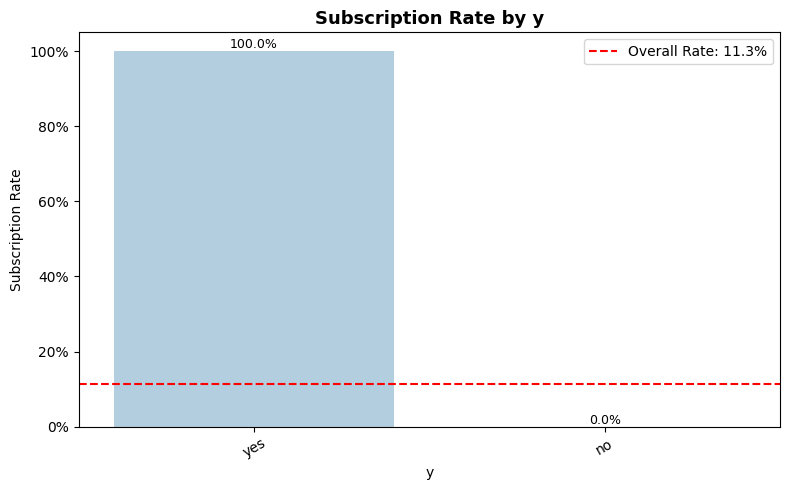

,y,subscription_rate,target
1,yes,1.0,100.0%
0,no,0.0,0.0%


In [21]:
# target vs categorical columns
overall_rate = df['y'].map({'no': 0, 'yes': 1}).mean()

for i in df.select_dtypes(include='object').columns:
    print(f"\nColumn: {i}")

    df_agg = (
        df.groupby([i])['y']
        .apply(lambda x: x.map({'no': 0, 'yes': 1}).mean())
        .reset_index(name='subscription_rate')
        .sort_values(by='subscription_rate', ascending=False)
      )

    n = len(df_agg)
    bar_colors = sns.color_palette('Blues', n)  # darkest = highest rate

    fig, ax = plt.subplots(figsize=(max(8, n * 0.8), 5))

    sns.barplot(
          data=df_agg,
          x=i,
          y='subscription_rate',
          palette=bar_colors,
          ax=ax
      )

    # Overall rate reference line
    ax.axhline(overall_rate, color='red', linestyle='--', linewidth=1.5, label=f'Overall Rate: {overall_rate:.1%}')

    # Annotate each bar with percentage
    for p in ax.patches:
        ax.annotate(
            f'{p.get_height():.1%}',
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha='center', va='bottom', fontsize=9
          )

    ax.set_title(f'Subscription Rate by {i}', fontsize=13, fontweight='bold')
    ax.set_xlabel(i, fontsize=10)
    ax.set_ylabel('Subscription Rate', fontsize=10)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda val, _: f'{val:.0%}'))
    ax.tick_params(axis='x', rotation=30)
    ax.legend()

    plt.tight_layout()
    plt.show()

    display(df_agg.assign(target=df_agg['subscription_rate'].map('{:.1%}'.format)))

    print("  " + "="*50)


**Ringkasan Analisis Bivariate (Kategorik vs Subscription)**

**Demografi & Sosial**

- Job → Subscription tertinggi pada student (31.4%) dan retired (25.3%), terendah pada blue-collar (6.9%). Nasabah dengan status pelajar dan pensiunan lebih responsif, sementara pekerja kasar paling rendah.

- Marital → Single memiliki subscription rate tertinggi (14.0%), lebih tinggi dari rata-rata (11.3%). Married dan divorced lebih rendah (~10%). Status lajang lebih terbuka terhadap campaign.

- Education → Subscription tertinggi pada illiterate (22.2%) dan university degree (13.8%), terendah basic.9y (7.8%). Pendidikan tinggi meningkatkan peluang subscription, namun ada anomali pada kelompok tidak berpendidikan.

**Profil Keuangan**

- Default → Nasabah dengan status no default memiliki subscription rate tertinggi (12.9%), unknown lebih rendah (5.2%), yes = 0%. Riwayat kredit bersih sangat berpengaruh positif.

- Housing → Subscription rate hampir sama, yes (11.6%) sedikit lebih tinggi dari no (10.9%)Kepemilikan rumah tidak terlalu membedakan.

- Loan → Subscription rate no loan (11.3%) sedikit lebih tinggi dari yes loan (10.9%). Pinjaman pribadi tidak terlalu memengaruhi.

**Campaign & Kontak**

- Contact → Cellular jauh lebih efektif (14.7%) dibanding telephone (5.2%). Ponsel adalah channel utama yang paling berhasil.

- Month → Subscription rate sangat tinggi di bulan Mar (50.5%), Dec (48.9%), Sep (44.9%), Oct (43.9%). Bulan May paling rendah (6.4%). Momentum campaign sangat menentukan, dengan puncak di bulan Maret–Oktober.

- Day_of_week → Subscription tertinggi di Thursday (12.1%), terendah di Monday (10.0%). Pertengahan minggu lebih efektif.

- Poutcome → Success menghasilkan subscription rate sangat tinggi (65.2%), failure 14.2%, nonexistent hanya 8.8%. Riwayat campaign sebelumnya sangat memengaruhi keberhasilan.

## **4.3 Correlation & Multicollinearity Check**

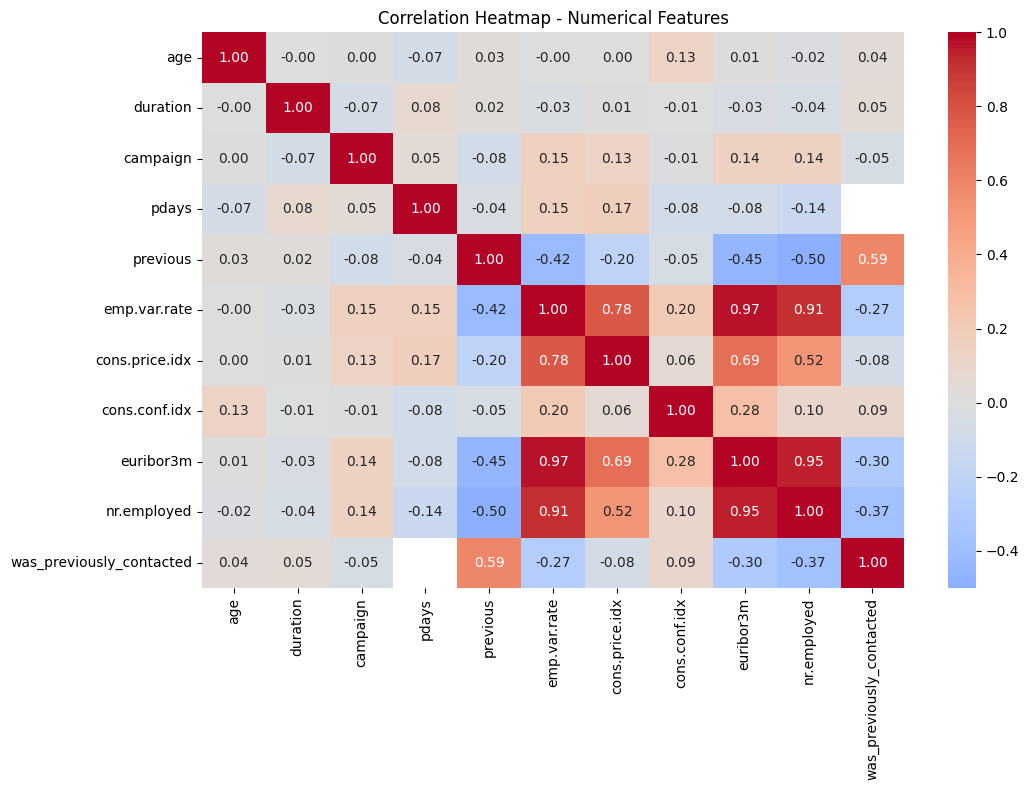

In [22]:
# Correlation heatmap
corr = df[numeric_features].corr()

plt.figure(figsize=(11, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap - Numerical Features")
plt.tight_layout()
plt.show()

### **Analisis Fitur Terpilih vs Subscription**

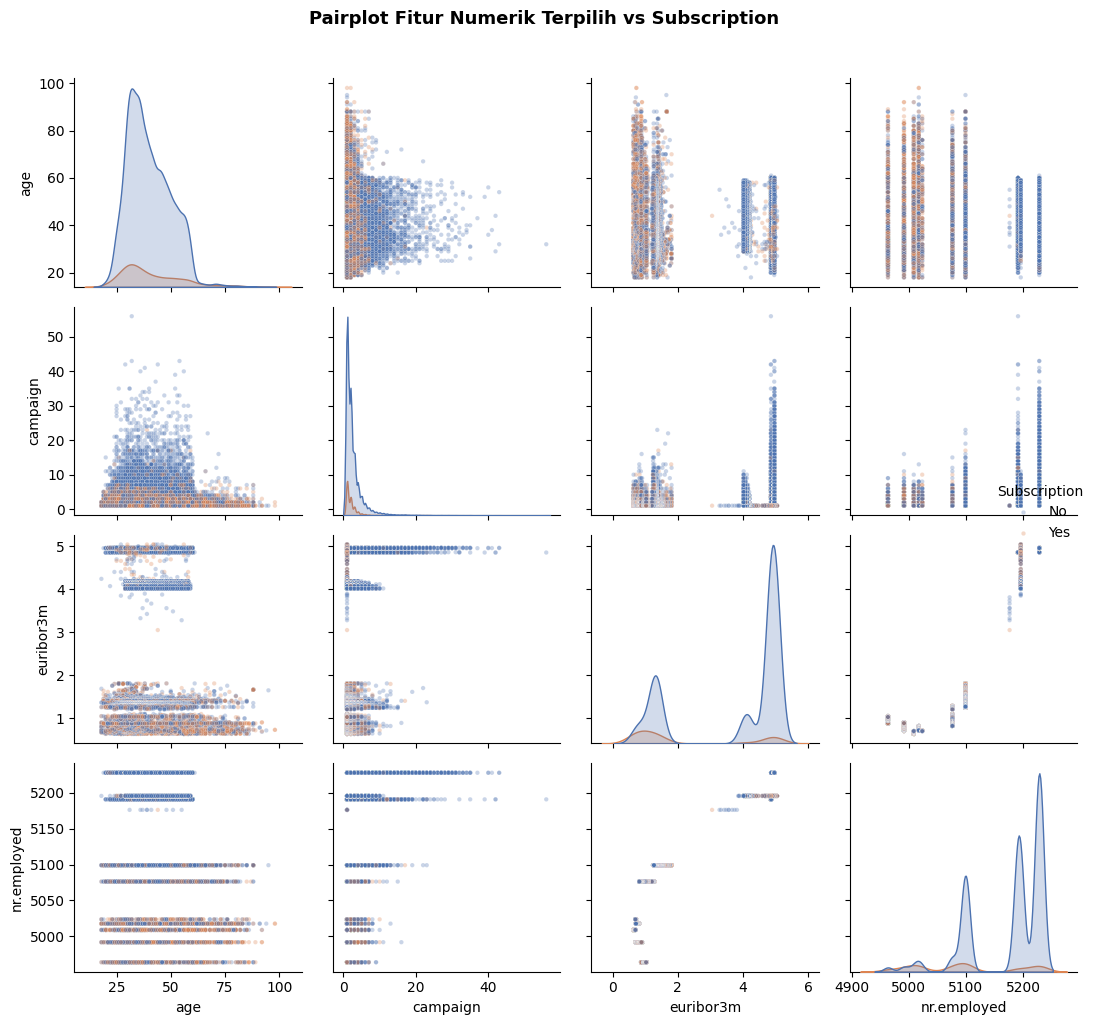

In [23]:
selected_num = ['age', 'campaign', 'euribor3m', 'nr.employed']

df_pairplot = df.loc[df.index, selected_num + ['y']].dropna().copy()
df_pairplot['Subscription'] = df_pairplot['y'].map({
    0: 'No', 1: 'Yes',
    'no': 'No', 'yes': 'Yes'
})

sns.pairplot(df_pairplot, hue='Subscription', palette={'No': '#4C72B0', 'Yes': '#DD8452'},
             vars=selected_num, plot_kws={'alpha': 0.3, 's': 10},
             diag_kind='kde')
plt.suptitle('Pairplot Fitur Numerik Terpilih vs Subscription', y=1.02, fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

> **Catatan:** `duration` tidak dimasukkan dalam analisis pairplot model karena 
berpotensi menyebabkan data leakage, nilainya baru diketahui setelah panggilan 
berlangsung. Analisis distribusi `duration` tetap disajikan secara terpisah sebagai 
referensi eksploratif.

In [24]:
print(df[selected_num].describe())
print(df['y'].value_counts())

                age      campaign     euribor3m   nr.employed
count  41167.000000  41167.000000  41167.000000  41167.000000
mean      40.026065      2.567712      3.621676   5167.048563
std       10.418017      2.770353      1.734264     72.247678
min       18.000000      1.000000      0.634000   4963.600000
25%       32.000000      1.000000      1.344000   5099.100000
50%       38.000000      2.000000      4.857000   5191.000000
75%       47.000000      3.000000      4.961000   5228.100000
max       98.000000     56.000000      5.045000   5228.100000
y
no     36530
yes     4637
Name: count, dtype: int64


# **Section 5. Data Preparation**

## **5.1 Initialization**

In [25]:
# Target encoding
df["y"] = df["y"].map({"no": 0, "yes": 1})

# define feature and target
feature = df.drop(columns=["y", "duration"]) #duration di drop untuk menghindari data leakage
target = df["y"]


> **Catatan:** `duration` menunjukkan korelasi kuat dengan target, namun tidak dimasukkan 
ke dalam model karena berpotensi menyebabkan data leakage. Nilainya baru diketahui 
setelah panggilan berlangsung, sehingga tidak dapat digunakan untuk targeting sebelum 
kontak terjadi.

 ## **5.2 Constructing Training and Testing Data**

In [26]:
x_train, x_test, y_train, y_test = train_test_split(
    feature, target, test_size=0.2, random_state=RANDOM_STATE, stratify=target
)

# TODO: reset index
x_train = x_train.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
x_test  = x_test.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

print("Train shape:", x_train.shape)
print("Test shape :", x_test.shape)

print("\ny_train distribution:")

Train shape: (32933, 20)
Test shape : (8234, 20)

y_train distribution:


## **5.3 Handling Imbalanced Data**

In [27]:
# Cek distribusi kelas
print(df["y"].value_counts())
print(df['y'].value_counts(normalize=True) * 100)
print("Class imbalance terdeteksi (~89% kelas no, ~11% kelas yes).")
print("Strategi: SMOTE akan diterapkan di dalam Pipeline pada data training saja.")
print("SMOTE TIDAK diterapkan pada data testing agar evaluasi tetap realistis.")

y
0    36530
1     4637
Name: count, dtype: int64
y
0    88.736124
1    11.263876
Name: proportion, dtype: float64
Class imbalance terdeteksi (~89% kelas no, ~11% kelas yes).
Strategi: SMOTE akan diterapkan di dalam Pipeline pada data training saja.
SMOTE TIDAK diterapkan pada data testing agar evaluasi tetap realistis.


## **5.4 Data Transformation (Feature Engineering)**

In [28]:
# Numerical features
numeric_features = [
    c for c in x_train.select_dtypes(include=np.number).columns
]

# Categorical features that has NaN (Needs an imputer)
unknown_cols = ['education', 'housing', 'loan', 'job', 'marital']

# Categorical features (No NaN)
categorical_features = [
    c for c in x_train.select_dtypes(include=["object"]).columns
    if c not in unknown_cols
]

# Binary feature
binary_features = [
    "was_previously_contacted"
]

# Jangan masukkan binary ke numerical pipeline
numeric_features = [
    c for c in numeric_features
    if c not in binary_features
]

print("Numerical   :", numeric_features)
print("Unknown cols:", unknown_cols)
print("Categorical :", categorical_features)
print("Binary      :", binary_features)
print(numeric_features)

Numerical   : ['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']
Unknown cols: ['education', 'housing', 'loan', 'job', 'marital']
Categorical : ['default', 'contact', 'month', 'day_of_week', 'poutcome']
Binary      : ['was_previously_contacted']
['age', 'campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed']


In [29]:
class P95Capper(BaseEstimator, TransformerMixin):
    """Cap kolom 'campaign' di P95, dihitung dari training data saja."""
    def __init__(self, col_idx):
        self.col_idx = col_idx

    def fit(self, X, y=None):
        self.cap_ = np.percentile(X[:, self.col_idx], 95)
        self.n_features_in_ = X.shape[1]
        return self

    def transform(self, X, y=None):
        X_ = X.copy()
        X_[:, self.col_idx] = np.clip(X_[:, self.col_idx], a_min=None, a_max=self.cap_)
        return X_

    def get_feature_names_out(self, input_features=None):
        if input_features is not None:
            return np.array(input_features)
        return np.array([f"x{i}" for i in range(self.n_features_in_)])

In [30]:
# Preprocessing
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
     ("capper", P95Capper(col_idx=2)),
    ("scaler", RobustScaler())
])

# Kolom kategorikal tanpa missing
categorical_pipeline = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Kolom kategorikal yang punya NaN (ex-unknown) -> imputer dulu baru encode
unknown_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ("num",     numeric_pipeline,     numeric_features),
        ("cat",     categorical_pipeline, categorical_features),
        ("unknown", unknown_pipeline,     unknown_cols),
        ("binary",  "passthrough",        binary_features)
    ])

base_pipeline = ImbPipeline([
    ("fitur_engineering", preprocessor),
    ("fitur_resampling", SMOTE(random_state=RANDOM_STATE)),
    ("classifier", LogisticRegression(random_state=RANDOM_STATE))
]
)

## **5.5 Feature Selection**

In [31]:
base_pipeline.fit(x_train, y_train)

,steps,"[('fitur_engineering', ...), ('fitur_resampling', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string read

In [32]:
# Ambil nama fitur setelah preprocessing
preprocessor_fitted = base_pipeline.named_steps["fitur_engineering"]
feature_names = preprocessor_fitted.get_feature_names_out()

print(f"Jumlah fitur : {len(feature_names)}")
print(list(feature_names))

Jumlah fitur : 58
['num__age', 'num__campaign', 'num__pdays', 'num__previous', 'num__emp.var.rate', 'num__cons.price.idx', 'num__cons.conf.idx', 'num__euribor3m', 'num__nr.employed', 'cat__default_no', 'cat__default_unknown', 'cat__default_yes', 'cat__contact_cellular', 'cat__contact_telephone', 'cat__month_apr', 'cat__month_aug', 'cat__month_dec', 'cat__month_jul', 'cat__month_jun', 'cat__month_mar', 'cat__month_may', 'cat__month_nov', 'cat__month_oct', 'cat__month_sep', 'cat__day_of_week_fri', 'cat__day_of_week_mon', 'cat__day_of_week_thu', 'cat__day_of_week_tue', 'cat__day_of_week_wed', 'cat__poutcome_failure', 'cat__poutcome_nonexistent', 'cat__poutcome_success', 'unknown__education_basic.4y', 'unknown__education_basic.6y', 'unknown__education_basic.9y', 'unknown__education_high.school', 'unknown__education_illiterate', 'unknown__education_professional.course', 'unknown__education_university.degree', 'unknown__housing_no', 'unknown__housing_yes', 'unknown__loan_no', 'unknown__loan_

## **5.6 Overview**

In [33]:
print("=" * 50)
print("RINGKASAN DATA PREPARATION")
print("=" * 50)
print(f"Training data : {x_train.shape[0]} baris x {x_train.shape[1]} kolom")
print(f"Testing data  : {x_test.shape[0]} baris x {x_test.shape[1]} kolom")
print(f"Jumlah fitur  : {len(feature)}")

RINGKASAN DATA PREPARATION
Training data : 32933 baris x 20 kolom
Testing data  : 8234 baris x 20 kolom
Jumlah fitur  : 41167


# **Section 6. Model Development**

## **6.1. Initialization**

In [34]:
# F2 scorer
f2_scorer = make_scorer(fbeta_score, beta=2)

# cross validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# scoring
scoring = {
    'recall'   : 'recall',
    'precision': 'precision',
    'f1'       : 'f1',
    'roc_auc'  : 'roc_auc',
    'f2'       : f2_scorer
}

def run_cv(base_pipeline, x_train, y_train):
    """Jalankan cross-validation dan kembalikan ringkasan metrik."""
    results = cross_validate(base_pipeline, x_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    summary = {}
    for m in scoring:
        scores = results[f'test_{m}']
        summary[m] = {'mean': scores.mean(), 'std': scores.std()}
    return summary

print("Cross-Validation: StratifiedKFold (5 fold)")
print("Metrik: Recall, Precision, F1, F2, ROC-AUC")

Cross-Validation: StratifiedKFold (5 fold)
Metrik: Recall, Precision, F1, F2, ROC-AUC


In [35]:
cv_result = run_cv(
    base_pipeline,
    x_train,
    y_train
)

In [36]:
# save to dataframe
cv_summary = pd.DataFrame(cv_result).T
cv_summary

,mean,std
recall,0.629380,0.022013
precision,0.333660,0.010663
f1,0.436017,0.012860
roc_auc,0.786874,0.011746
f2,0.534499,0.016489


## **6.2 Developing the Model Pipeline**

In [37]:
def make_pipeline(model):
    """Buat ImbPipeline: preprocessor -> SMOTE -> model."""
    return ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote',        SMOTE(random_state=RANDOM_STATE)),
        ('model',        model)
    ])

print("Pipeline: preprocessor -> SMOTE -> model")
print("Keunggulan: preprocessing di-fit hanya pada training fold (no data leakage).")

Pipeline: preprocessor -> SMOTE -> model
Keunggulan: preprocessing di-fit hanya pada training fold (no data leakage).


In [38]:
# Initialize model
logreg   = LogisticRegression(random_state=RANDOM_STATE, class_weight="balanced")
knn      = KNeighborsClassifier()
dt       = DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight="balanced")
rf       = RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced")
gb       = GradientBoostingClassifier(random_state=RANDOM_STATE)
adaboost = AdaBoostClassifier(random_state=RANDOM_STATE)

In [39]:
list_models = {
    "LogisticRegression"     : logreg,
    "KNN"                    : knn,
    "DecisionTreeClassifier" : dt,
    "RandomForestClassifier" : rf,
    "GradientBoost"          : gb,
    "AdaBoost"               : adaboost,
}

## **6.3 Model Benchmarking**

### 6.3.1 Model Benchmarking (with resampling)

In [40]:
# Benchmark model function
def benchmark_models(pipeline, list_models, x_train, y_train, 
                      scoring=f2_scorer, cv=5, random_state=RANDOM_STATE):
    """""
    Benchmark beberapa model classifier menggunakan cross-validation
    di atas satu pipeline yang sama (hanya step 'classifier' yang diganti).

    Parameters
    ----------
    pipeline : sklearn Pipeline
        Pipeline yang punya step bernama 'classifier' (mis. model_res_pipeline).
    list_models : dict
        {"nama_model": estimator, ...}
    x_train, y_train : array-like
        Data training.
    scoring : str
        Metric untuk cross_validate (default "f1").
    cv : int
        Jumlah fold untuk StratifiedKFold (default 5).
    random_state : int or None
        Untuk shuffle di StratifiedKFold, jika ingin reproducible.

    Returns
    -------
    pd.DataFrame
        Ringkasan mean & std train/test score per model, diurutkan
        berdasarkan mean_test_score tertinggi.
    """
    all_cv_result = []

    skf = StratifiedKFold(
        n_splits=cv,
        shuffle=random_state is not None,
        random_state=random_state
    )

    for name, model in list_models.items():
        classifier = pipeline.set_params(classifier=model)
        cv_result = cross_validate(
            estimator=classifier,
            X=x_train, y=y_train,
            cv=skf,
            scoring=scoring,
            return_train_score=True
        )
        all_cv_result.append({
            "name": name,
            "mean_train_score": np.mean(cv_result["train_score"]),
            "std_train_score": np.std(cv_result["train_score"]),
            "mean_test_score": np.mean(cv_result["test_score"]),
            "std_test_score": np.std(cv_result["test_score"])
        })

    df_result = pd.DataFrame(all_cv_result).sort_values(
        "mean_test_score", ascending=False
    ).reset_index(drop=True)

    return df_result

In [41]:
# With resampling
benchmark_result = benchmark_models(
    base_pipeline, 
    list_models,
    x_train, 
    y_train, 
    scoring=f2_scorer,
    cv=5, 
    random_state=RANDOM_STATE
)

benchmark_result['gap']       = (benchmark_result['mean_train_score'] - benchmark_result['mean_test_score']).round(4)
benchmark_result['mean_train_score'] = benchmark_result['mean_train_score'].round(4)
benchmark_result['mean_test_score']  = benchmark_result['mean_test_score'].round(4)
benchmark_result['std_test_score']   = benchmark_result['std_test_score'].round(4)

display(benchmark_result)

,name,mean_train_score,std_train_score,mean_test_score,std_test_score,gap
0,LogisticRegression,0.5380,0.003283,0.5348,0.0166,0.0032
1,AdaBoost,0.5092,0.011289,0.5076,0.0102,0.0017
2,GradientBoost,0.4949,0.007117,0.4777,0.0187,0.0172
3,KNN,0.7685,0.002639,0.4556,0.0108,0.3129
4,RandomForestClassifier,0.9771,0.001157,0.3752,0.0081,0.6019
5,DecisionTreeClassifier,0.9694,0.000882,0.3287,0.0184,0.6407


**Observasi — CV Analysis (Underfitting / Stability / Overfitting):**

| Indikator | Threshold | Interpretasi |
|---|---|---|
| `mean_test_score` rendah | < 0.50 | Underfitting |
| `std_test_score` tinggi | > 0.05 | Tidak stabil antar fold |
| `gap` besar | > 0.10 | Overfitting |

- **LogisticRegression**: CV mean tertinggi (0.5348) dengan gap sangat kecil (0.003) 
dan std terendah (0.017) — paling stabil dan konsisten antar fold. Kandidat terkuat.
- **GradientBoost**: CV mean 0.4777, dengan gap kecil (0.017). Performa sedikit di bawah threshold underfitting, tapi stabilitas cukup baik untuk dilanjutkan ke tuning.
- **AdaBoost**: CV mean 0.5076, gap terkecil dari semua model (0.002) sangat stabil meski performanya sedikit di bawah LogReg. Layak dilanjutkan ke tuning.
- **KNN**: Train score 0.769 vs CV 0.456, gap 0.313. Overfitting signifikan. Tidak dilanjutkan ke tuning.
- **RandomForest**: Train score hampir sempurna (0.977) vs CV 0.375, gap 0.602 overfitting yang signifikan. Tidak dilanjutkan ke tuning.
- **DecisionTree**: Train score 0.969 vs CV 0.329, gap 0.641. Overfitting paling parah dari semua model. Tidak dilanjutkan ke tuning.

> **Kesimpulan:** GradientBoost, AdaBoost, dan LogisticRegression dipilih untuk lanjut ke hyperparameter tuning berdasarkan kombinasi CV mean tertinggi, gap terkecil, dan std yang stabil.

### 6.3.2 Model Ensamble Benchmarking

### 6.3.2.1 Various Type

In [42]:
# model initialization
voting = VotingClassifier(estimators=[("rf", rf), ("dt", dt), ("knn", knn)])
stacking = StackingClassifier(estimators=[("rf", rf), ("dt", dt), ("knn", knn)],
                              final_estimator=gb)

In [43]:
# benchmark process
benchmark_various = benchmark_models(pipeline=base_pipeline, list_models={"voting": voting, "stacking": stacking}, x_train=x_train,y_train=y_train,
                    scoring=f2_scorer,
                    cv=5,
                    random_state=RANDOM_STATE)

In [44]:
benchmark_various

,name,mean_train_score,std_train_score,mean_test_score,std_test_score
0,voting,0.976874,0.001358,0.410978,0.013434
1,stacking,0.969239,0.003322,0.381675,0.008675


## **6.4 Tune Model**

In [45]:
from scipy.stats import randint, uniform
from sklearn.model_selection import RandomizedSearchCV

f2_scorer = make_scorer(fbeta_score, beta=2)

### **6.4.1 GradientBoost Tuning**

In [46]:
GB_PATH = '../model/GradientBoost_tuned.joblib'

if os.path.exists(GB_PATH):
    data           = joblib.load(GB_PATH)
    tuned_gb       = data['model']
    gb_cv_score    = joblib.load(GB_PATH)['best_score']
    print("GradientBoost loaded, skipping tuning.")
    print("Best F2 (CV)     :", round(gb_cv_score, 4))
else:
    param_dist_gb = {
        "model__n_estimators"    : randint(100, 400),
        "model__learning_rate"   : uniform(0.01, 0.2),
        "model__max_depth"       : randint(3, 7),
        "model__subsample"       : uniform(0.7, 0.3),
        "model__min_samples_leaf": randint(10, 50),
    }
    rs_gb = RandomizedSearchCV(
        make_pipeline(GradientBoostingClassifier(random_state=RANDOM_STATE)),
        param_distributions=param_dist_gb,
        n_iter=50, scoring=f2_scorer,
        cv=cv, n_jobs=-1, random_state=RANDOM_STATE,
        return_train_score=True
    )
    rs_gb.fit(x_train, y_train)
    tuned_gb       = rs_gb.best_estimator_
    gb_cv_score    = rs_gb.best_score_
    gb_best_params = rs_gb.best_params_
    os.makedirs(r'..\model', exist_ok=True)
    joblib.dump({'model': tuned_gb, 'best_score': gb_cv_score, 'best_params': gb_best_params}, GB_PATH)
    print("Best params (GB) :", gb_best_params)
    print("Best F2 (CV)     :", round(gb_cv_score, 4))

GradientBoost loaded, skipping tuning.
Best F2 (CV)     : 0.5298


#### Evaluation Before VS After Tuning

In [47]:
from sklearn.base import clone

base_gb = make_pipeline(GradientBoostingClassifier(random_state=RANDOM_STATE))
base_gb.fit(x_train, y_train)

tuned_gb.fit(x_train, y_train)

# Before
y_train_pred = base_gb.predict(x_train)
y_test_pred  = base_gb.predict(x_test)
print("Base GradientBoosting")
print(f"  Train F2 : {fbeta_score(y_train, y_train_pred, beta=2):.4f}")
print(f"  Test  F2 : {fbeta_score(y_test,  y_test_pred,  beta=2):.4f}")

# After
y_train_pred = tuned_gb.predict(x_train)
y_test_pred  = tuned_gb.predict(x_test)
print("\nTuned GradientBoosting")
print(f"  Train F2 : {fbeta_score(y_train, y_train_pred, beta=2):.4f}")
print(f"  Test  F2 : {fbeta_score(y_test,  y_test_pred,  beta=2):.4f}")

Base GradientBoosting
  Train F2 : 0.4992
  Test  F2 : 0.4981

Tuned GradientBoosting
  Train F2 : 0.5371
  Test  F2 : 0.5633


### **6.4.2 AdaBoost Tuning**

In [48]:
ADA_PATH = '../model/AdaBoost_tuned.joblib'

if os.path.exists(ADA_PATH):
    tuned_ada    = joblib.load(ADA_PATH)['model']
    ada_cv_score = joblib.load(ADA_PATH)['best_score']
    print("AdaBoost loaded, skipping tuning.")
    print("Best F2 (CV)     :", round(ada_cv_score, 4))
else:
    param_dist_ada = {
        "model__n_estimators" : randint(50, 300),
        "model__learning_rate": uniform(0.01, 1.5),
    }

    rs_ada = RandomizedSearchCV(
        make_pipeline(AdaBoostClassifier(random_state=RANDOM_STATE)),
        param_distributions=param_dist_ada,
        n_iter=50, scoring=f2_scorer,
        cv=cv, n_jobs=-1, random_state=RANDOM_STATE,
        return_train_score=True
    )
    rs_ada.fit(x_train, y_train)
    tuned_ada    = rs_ada.best_estimator_
    ada_cv_score = rs_ada.best_score_
    os.makedirs('../model', exist_ok=True)
    joblib.dump({'model': tuned_ada, 'best_score': ada_cv_score}, ADA_PATH)
    print("Best params (Ada):", rs_ada.best_params_)
    print("Best F2 (CV)     :", round(ada_cv_score, 4))

AdaBoost loaded, skipping tuning.
Best F2 (CV)     : 0.5289


#### Evaluation Before VS After Tuning

In [49]:
base_ada = make_pipeline(AdaBoostClassifier(random_state=RANDOM_STATE))
base_ada.fit(x_train, y_train)

# Before
y_train_pred = base_ada.predict(x_train)
y_test_pred  = base_ada.predict(x_test)
print("Base AdaBoost")
print(f"  Train F2 : {fbeta_score(y_train, y_train_pred, beta=2):.4f}")
print(f"  Test  F2 : {fbeta_score(y_test,  y_test_pred,  beta=2):.4f}")

# After
x_train_processed = tuned_gb.named_steps['preprocessor'].transform(x_train)
x_test_processed  = tuned_gb.named_steps['preprocessor'].transform(x_test)

y_train_pred = tuned_ada.predict(x_train)
y_test_pred  = tuned_ada.predict(x_test)
print("\nTuned AdaBoost")
print(f"  Train F2 : {fbeta_score(y_train, y_train_pred, beta=2):.4f}")
print(f"  Test  F2 : {fbeta_score(y_test,  y_test_pred,  beta=2):.4f}")

Base AdaBoost
  Train F2 : 0.5228
  Test  F2 : 0.5485

Tuned AdaBoost
  Train F2 : 0.5255
  Test  F2 : 0.5543


### **6.4.3 Logistic Regression Tuning**

In [50]:
LR_PATH = '../model/LogReg_tuned.joblib'

if os.path.exists(LR_PATH):
    tuned_logreg = joblib.load(LR_PATH)['model']
    lr_cv_score  = joblib.load(LR_PATH)['best_score']
    print("LogReg loaded, skipping tuning.")
    print("Best F2 (CV)     :", round(lr_cv_score, 4))
else:
    param_dist_logreg = {
        "model__C"       : uniform(0.001, 10),
        "model__solver"  : ["lbfgs", "liblinear"],
        "model__max_iter": [300, 500, 1000],
    }

    rs_logreg = RandomizedSearchCV(
        make_pipeline(LogisticRegression(
            random_state=RANDOM_STATE, class_weight="balanced")),
        param_distributions=param_dist_logreg,
        n_iter=30, scoring=f2_scorer,
        cv=cv, n_jobs=-1, random_state=RANDOM_STATE,
        return_train_score=True
    )
    rs_logreg.fit(x_train, y_train)
    tuned_logreg = rs_logreg.best_estimator_
    lr_cv_score  = rs_logreg.best_score_
    os.makedirs('../model', exist_ok=True)
    joblib.dump({'model': tuned_logreg, 'best_score': lr_cv_score}, LR_PATH)
    print("Best params (LR) :", rs_logreg.best_params_)
    print("Best F2 (CV)     :", round(lr_cv_score, 4))

LogReg loaded, skipping tuning.
Best F2 (CV)     : 0.5371


#### Evaluation Before VS After Tuning

In [51]:
base_logreg = make_pipeline(LogisticRegression(random_state=RANDOM_STATE, class_weight="balanced"))
base_logreg.fit(x_train, y_train)

# Before
y_train_pred = base_logreg.predict(x_train)
y_test_pred  = base_logreg.predict(x_test)
print("Base Logistic Regression")
print(f"  Train F2 : {fbeta_score(y_train, y_train_pred, beta=2):.4f}")
print(f"  Test  F2 : {fbeta_score(y_test,  y_test_pred,  beta=2):.4f}")

# After
y_train_pred = tuned_logreg.predict(x_train)
y_test_pred  = tuned_logreg.predict(x_test)
print("\nTuned Logistic Regression")
print(f"  Train F2 : {fbeta_score(y_train, y_train_pred, beta=2):.4f}")
print(f"  Test  F2 : {fbeta_score(y_test,  y_test_pred,  beta=2):.4f}")

Base Logistic Regression
  Train F2 : 0.5389
  Test  F2 : 0.5577

Tuned Logistic Regression
  Train F2 : 0.5403
  Test  F2 : 0.5598


### **6.4.4 Comparing Tuning Results**

In [52]:
tuning_rows = []

for name, tuned_model, cv_score in [
    ("GradientBoosting", tuned_gb,     gb_cv_score),
    ("AdaBoost",         tuned_ada,    ada_cv_score),
    ("LogReg",           tuned_logreg, lr_cv_score),
]:
    y_pred  = tuned_model.predict(x_test)
    y_proba = tuned_model.predict_proba(x_test)[:, 1]

    tuning_rows.append({
        "Model"         : name,
        "Best CV F2"    : round(cv_score, 4),
        "Test F2"       : round(fbeta_score(y_test, y_pred, beta=2), 4),
        "Test Recall"   : round(recall_score(y_test, y_pred), 4),
        "Test Precision": round(precision_score(y_test, y_pred), 4),
        "ROC-AUC"       : round(roc_auc_score(y_test, y_proba), 4),
    })

tuning_df = pd.DataFrame(tuning_rows).sort_values("Test F2", ascending=False).reset_index(drop=True)
display(tuning_df)

,Model,Best CV F2,Test F2,Test Recall,Test Precision,ROC-AUC
0,GradientBoosting,0.5298,0.5633,0.6095,0.4323,0.8014
1,LogReg,0.5371,0.5598,0.6634,0.3445,0.8040
2,AdaBoost,0.5289,0.5543,0.6117,0.4030,0.7967


### **6.4.5 Choosing Best Model**

In [53]:
best_model = tuned_logreg

os.makedirs('../model', exist_ok=True)
joblib.dump({'model': tuned_gb,     'best_score': gb_cv_score},  '../model/GradientBoost_tuned.joblib')
joblib.dump({'model': tuned_ada,    'best_score': ada_cv_score},  '../model/AdaBoost_tuned.joblib')
joblib.dump({'model': tuned_logreg, 'best_score': lr_cv_score},   '../model/LogReg_tuned.joblib')
joblib.dump({'model': best_model,   'best_score': gb_cv_score},   '../model/best_model.joblib')
print("All models saved.")

clf = best_model.named_steps['model']
print(f"Best model  : {clf.__class__.__name__}")
print(f"Parameters  :")
for param, value in clf.get_params().items():
    print(f"  {param}: {value}")
print(f"\nTest F2     : {fbeta_score(y_test, best_model.predict(x_test), beta=2):.4f}")
print(f"Test Recall : {recall_score(y_test, best_model.predict(x_test)):.4f}")
print(f"Test ROC-AUC: {roc_auc_score(y_test, best_model.predict_proba(x_test)[:,1]):.4f}")

All models saved.
Best model  : LogisticRegression
Parameters  :
  C: 0.10474153885699955
  class_weight: balanced
  dual: False
  fit_intercept: True
  intercept_scaling: 1
  l1_ratio: 0.0
  max_iter: 1000
  n_jobs: None
  penalty: deprecated
  random_state: 9
  solver: liblinear
  tol: 0.0001
  verbose: 0
  warm_start: False

Test F2     : 0.5598
Test Recall : 0.6634
Test ROC-AUC: 0.8040


## **6.5 Analyze Model**

&emsp;&emsp;&emsp;Analisis model dilakukan pada data testing untuk mengevaluasi performa nyata model di luar data training. Metrik yang digunakan: **Confusion Matrix**, **Classification Report** (Precision, Recall, F1, F2), dan **ROC-AUC**.

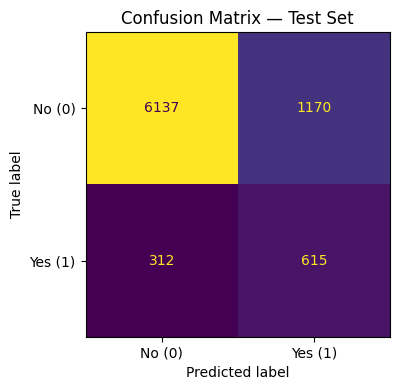

Classification Report:
              precision    recall  f1-score   support

          No       0.95      0.84      0.89      7307
         Yes       0.34      0.66      0.45       927

    accuracy                           0.82      8234
   macro avg       0.65      0.75      0.67      8234
weighted avg       0.88      0.82      0.84      8234

Recall    : 0.6634
Precision : 0.3445
F2-Score  : 0.5598
ROC-AUC   : 0.8040


In [54]:
# Evaluasi model terbaik pada data testing
y_pred  = best_model.predict(x_test)
y_proba = best_model.predict_proba(x_test)[:, 1]

# Confusion Matrix
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred, ax=ax,
    display_labels=["No (0)", "Yes (1)"], colorbar=False)
ax.set_title("Confusion Matrix — Test Set")
plt.tight_layout()
plt.show()

# Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=["No", "Yes"]))

# Key metrics
recall_val    = recall_score(y_test, y_pred)
precision_val = precision_score(y_test, y_pred)
f2_val        = fbeta_score(y_test, y_pred, beta=2)
roc_auc_val   = roc_auc_score(y_test, y_proba)

print(f"Recall    : {recall_val:.4f}")
print(f"Precision : {precision_val:.4f}")
print(f"F2-Score  : {f2_val:.4f}")
print(f"ROC-AUC   : {roc_auc_val:.4f}")

## **6.6 Model Calibration (Classification Only)**

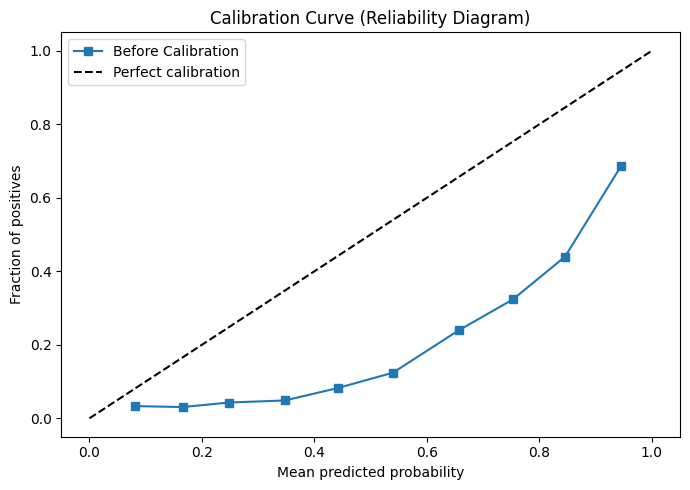

In [55]:
from sklearn.calibration import calibration_curve, CalibratedClassifierCV

# Plot calibration curve
fig, ax = plt.subplots(figsize=(7, 5))

fraction_of_positives, mean_predicted_value = calibration_curve(y_test, y_proba, n_bins=10)
ax.plot(mean_predicted_value, fraction_of_positives, "s-", label="Before Calibration")
ax.plot([0, 1], [0, 1], "k--", label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Calibration Curve (Reliability Diagram)")
ax.legend()
plt.tight_layout()
plt.show()

> **Observation:** Model menunjukkan pola underconfident — probabilitas yang diprediksi secara konsisten lebih rendah dari actual positive rate di seluruh range. Ini agak tidak biasa untuk Logistic Regression yang umumnya lebih well-calibrated dibanding tree-based models, kemungkinan disebabkan oleh class imbalance yang ditangani SMOTE saat training. Namun untuk tujuan proyek ini (prioritisasi panggilan berdasarkan ranking skor), kalibrasi yang sempurna tidak diperlukan. Yang penting adalah model mampu membedakan nasabah yang berpotensi subscribe vs tidak secara relatif, bukan nilai probabilitas absolutnya.

## **6.7 Model Explanation and Interpretation**


### 6.7.1 Feature Importance


In [56]:
preprocessor_step = best_model.named_steps['preprocessor']
feature_names_all = preprocessor_step.get_feature_names_out()

print(f"Total features after preprocessing: {len(feature_names_all)}")
print(f"Features: {list(feature_names_all)}")

Total features after preprocessing: 58
Features: ['num__age', 'num__campaign', 'num__pdays', 'num__previous', 'num__emp.var.rate', 'num__cons.price.idx', 'num__cons.conf.idx', 'num__euribor3m', 'num__nr.employed', 'cat__default_no', 'cat__default_unknown', 'cat__default_yes', 'cat__contact_cellular', 'cat__contact_telephone', 'cat__month_apr', 'cat__month_aug', 'cat__month_dec', 'cat__month_jul', 'cat__month_jun', 'cat__month_mar', 'cat__month_may', 'cat__month_nov', 'cat__month_oct', 'cat__month_sep', 'cat__day_of_week_fri', 'cat__day_of_week_mon', 'cat__day_of_week_thu', 'cat__day_of_week_tue', 'cat__day_of_week_wed', 'cat__poutcome_failure', 'cat__poutcome_nonexistent', 'cat__poutcome_success', 'unknown__education_basic.4y', 'unknown__education_basic.6y', 'unknown__education_basic.9y', 'unknown__education_high.school', 'unknown__education_illiterate', 'unknown__education_professional.course', 'unknown__education_university.degree', 'unknown__housing_no', 'unknown__housing_yes', 'unk

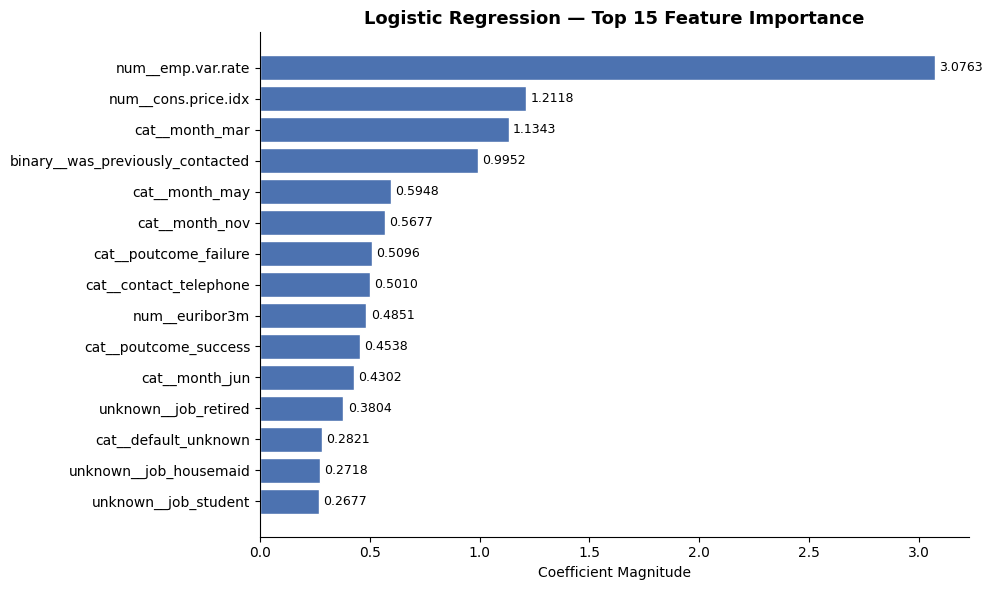

,Feature,Importance
0,num__emp.var.rate,3.076280
1,num__cons.price.idx,1.211844
2,cat__month_mar,1.134291
3,binary__was_previously_contacted,0.995158
4,cat__month_may,0.594842
5,cat__month_nov,0.567672
6,cat__poutcome_failure,0.509577
7,cat__contact_telephone,0.501042
8,num__euribor3m,0.485057
9,cat__poutcome_success,0.453841


In [57]:
lr_clf      = best_model.named_steps['model']
importances = np.abs(lr_clf.coef_[0])

feature_imp_df = pd.DataFrame({
    'Feature'   : feature_names_all,
    'Importance': importances
}).sort_values('Importance', ascending=False).reset_index(drop=True)

top_n = 15
plot_df = feature_imp_df.head(top_n)

plt.figure(figsize=(10, 6))
bars = plt.barh(
    plot_df['Feature'][::-1],
    plot_df['Importance'][::-1],
    color='#4C72B0',
    edgecolor='white'
)
plt.bar_label(bars, fmt='%.4f', padding=3, fontsize=9)
plt.xlabel('Coefficient Magnitude')
plt.title('Logistic Regression — Top 15 Feature Importance', fontsize=13, fontweight='bold')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

display(feature_imp_df.head(top_n))

**Observasi — Feature Importance (GradientBoost):**

Lima fitur teratas yang paling berpengaruh dalam model Logistic Regression adalah:

1. **emp.var.rate** — Employment variation rate mendominasi dengan margin yang sangat jauh (3.07 vs fitur lainnya <1.3). Kondisi ketenagakerjaan yang memburuk berkorelasi kuat dengan keputusan nasabah untuk mengunci dana di deposito sebagai instrumen aman.

2. **`cons.price.idx`** — Indeks harga konsumen mencerminkan tingkat inflasi yang sedang berlangsung. Saat harga barang meningkat, nasabah cenderung mempertimbangkan instrumen keuangan yang memberikan return tetap seperti deposito.

3. **`month_mar`** — Kampanye yang dilakukan di bulan Maret memiliki pengaruh signifikan terhadap keberhasilan konversi. Ini kemungkinan berkaitan dengan pola musiman perilaku keuangan nasabah di awal kuartal.

4. **`was_previously_contacted`** — Nasabah yang pernah dihubungi sebelumnya jauh lebih berpotensi subscribe. Ini mengonfirmasi bahwa familiarity dengan produk adalah sinyal kuat dalam pengambilan keputusan.

5. **`month_may`** — Bulan Mei memiliki pengaruh negatif terhadap konversi, menunjukkan bahwa timing kampanye sangat mempengaruhi hasil.

> **Implikasi bisnis:** Model ini menunjukkan bahwa kapan kampanye dijalankan (bulan dan kondisi makroekonomi) lebih dominan dibanding karakteristik demografis nasabah. Tim kampanye sebaiknya mempertimbangkan timing berdasarkan kondisi employment dan inflasi, serta memprioritaskan nasabah yang pernah dihubungi sebelumnya.

In [58]:
import shap

# Get preprocessed data
x_test_preprocessed = best_model.named_steps['preprocessor'].transform(x_test)
x_test_preprocessed_df = pd.DataFrame(x_test_preprocessed, columns=feature_names_all)

classifier = best_model.named_steps['model']

In [59]:
explainer   = shap.LinearExplainer(classifier, x_test_preprocessed_df)
shap_values = explainer.shap_values(x_test_preprocessed_df)

shap_values_subscribe = shap_values

Background dataset has 8234 samples but max_samples=100. Subsampling to 100 samples for SHAP value computation. To use all samples, set max_samples=8234 when initializing the masker.


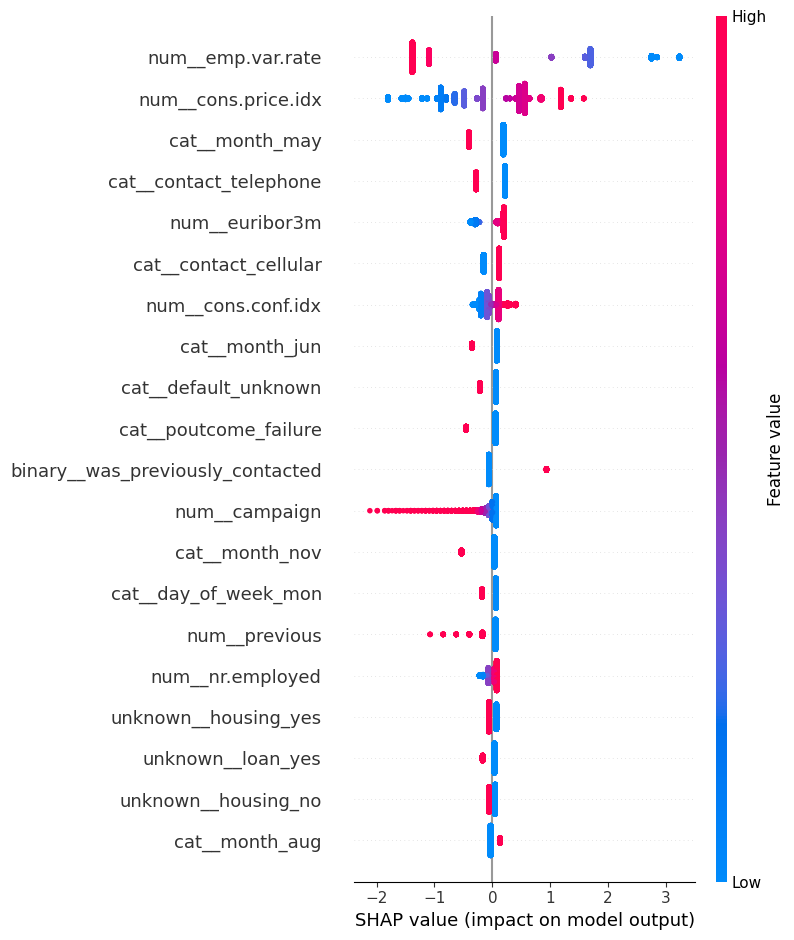

In [60]:
shap.summary_plot(shap_values_subscribe, x_test_preprocessed_df)

**Observasi — SHAP Summary Plot (Beeswarm):**

Plot ini menunjukkan kontribusi setiap fitur terhadap prediksi model per individu nasabah:

- **`emp.var.rate`**: Nilai tinggi (merah) tersebar jauh ke sisi positif hingga SHAP >3, menunjukkan bahwa kondisi ketenagakerjaan yang memburuk secara konsisten mendorong probabilitas subscribe. Fitur ini memiliki spread terluas — dampaknya paling dominan di seluruh nasabah.

- **`cons.price.idx`**: Nilai rendah (biru) mendorong SHAP positif, artinya saat indeks harga konsumen rendah, nasabah lebih cenderung subscribe. Ini konsisten dengan logika bahwa tekanan inflasi rendah membuat nasabah lebih nyaman mengunci dana di deposito.

- **`month_may`**: Konsisten mendorong SHAP negatif — kampanye di bulan Mei secara sistematis menurunkan probabilitas subscribe. Tim kampanye sebaiknya menghindari atau menyesuaikan strategi di bulan ini.

- **`was_previously_contacted`**: Nilai tinggi (pernah dihubungi) mendorong SHAP positif, mengonfirmasi bahwa familiarity dengan produk meningkatkan peluang konversi.

- **`campaign`**: Nilai tinggi (merah, banyak kontak) justru mendorong SHAP sangat negatif — terlalu sering menghubungi nasabah dalam satu kampanye menurunkan peluang subscribe secara signifikan.

> **Catatan:** Beeswarm plot menunjukkan distribusi dampak per individu, bukan rata-rata. Ini lebih informatif dari bar chart karena terlihat fitur mana yang konsisten vs yang bervariasi dampaknya.

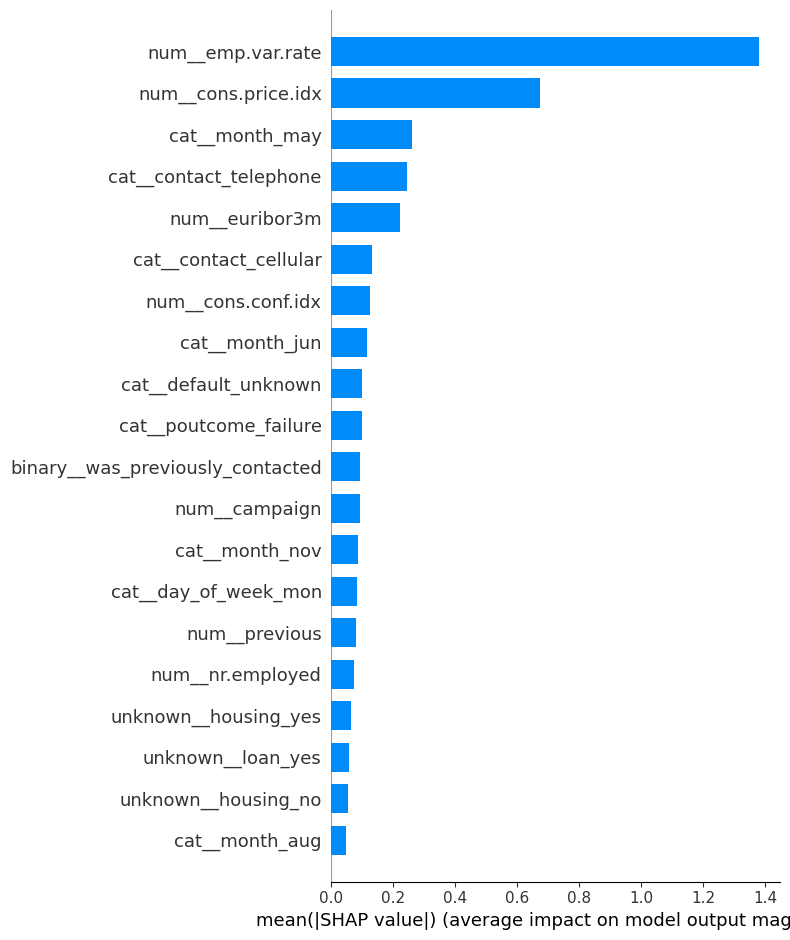

In [61]:
shap.summary_plot(shap_values_subscribe, x_test_preprocessed_df, plot_type="bar")

**Observasi — SHAP Bar Plot (Mean Absolute SHAP Value):**

Plot ini merangkum *rata-rata dampak absolut* setiap fitur terhadap prediksi model (tanpa mempertimbangkan arah/positif-negatif):

- **`campaign`** dan **`emp.var.rate`** memimpin dengan margin yang sangat jauh (>0.4) — jumlah tenaga kerja dalam ekonomi adalah fitur paling informatif dalam model ini, mencerminkan bahwa kondisi makroekonomi secara keseluruhan sangat menentukan keputusan nasabah.
- **`campaign`** dan **`emp.var.rate`** berada di posisi kedua dan ketiga — frekuensi kontak dan kondisi ketenagakerjaan sama-sama berpengaruh besar, menunjukkan bahwa bagaimana dan kapan nasabah dihubungi lebih penting dari karakteristik nasabahnya sendiri.
- **`Channel kontak`**(`contact_telephone`, `contact_cellular`) masuk top features — pemilihan media komunikasi secara signifikan mempengaruhi hasil kampanye.
- **Fitur demografis** (`job`, `education`) berada di posisi bawah — konsisten dengan temuan bahwa siapa nasabahnya kurang berpengaruh dibanding konteks ekonomi dan kampanye.

> **Kesimpulan:** Model sangat dipengaruhi oleh (1) kondisi makroekonomi saat kampanye berjalan (nr.employed, emp.var.rate), (2) intensitas dan channel kontak (campaign, contact_telephone), dan (3) sentimen ekonomi konsumen. Ini menunjukkan bahwa kapan dan bagaimana nasabah dihubungi jauh lebih berpengaruh dari siapa nasabahnya secara demografis.

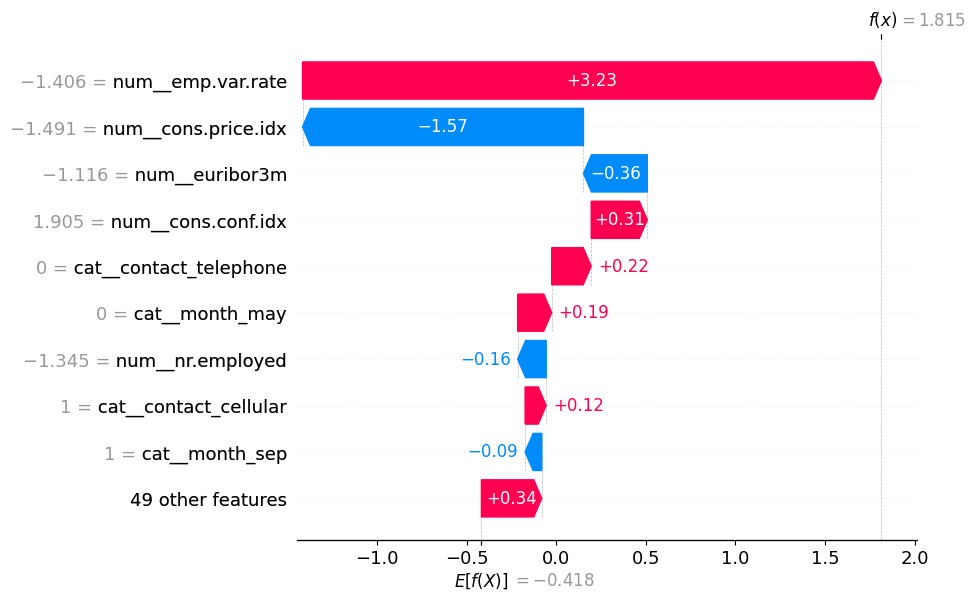

In [62]:
subscribe_indices = np.where(best_model.predict(x_test) == 1)[0]

shap_exp = shap.Explanation(
    values=shap_values_subscribe,
    base_values=explainer.expected_value,
    data=x_test_preprocessed_df.values,
    feature_names=feature_names_all
)

shap.plots.waterfall(shap_exp[subscribe_indices[0]])

**Observasi — SHAP Waterfall Plot (Individual Prediction):**

Waterfall plot ini menampilkan breakdown prediksi untuk satu nasabah yang diprediksi subscribe (dari test set). Cara membaca:

- **Base value (E[f(X)]= 0.052)**: Rata-rata prediksi model jika tidak ada informasi fitur apapun — merupakan titik awal (baseline log-odds).
- **Nilai merah (positif)**: Fitur yang mendorong prediksi ke arah "subscribe" — meningkatkan probabilitas.
- **Nilai biru (negatif)**: Fitur yang menurunkan probabilitas subscribe.
- **f(X) = 1.39**: Prediksi akhir model untuk nasabah ini — jauh di atas baseline, artinya model sangat yakin nasabah ini akan subscribe.

Untuk nasabah ini:
- **nr.employed** (+1.07) mendominasi secara absolut — kondisi ketenagakerjaan yang rendah (-1.345) mendorong probabilitas subscribe sangat tinggi, konsisten dengan temuan bahwa nasabah cenderung mencari instrumen aman saat kondisi ekonomi tidak stabil.
- **euribor3m** (+0.15) dan emp.var.rate (+0.15) turut mendorong prediksi positif — keduanya bernilai rendah/negatif, yang sesuai dengan pola beeswarm plot sebelumnya.
- **was_previously_contacted** (-0.07) memberikan kontribusi negatif kecil karena nasabah ini belum pernah dihubungi sebelumnya (nilai = 0).
- **poutcome_success** (-0.04) juga negatif karena nasabah tidak memiliki riwayat konversi sebelumnya.

> **Kegunaan bisnis:** Plot ini berguna untuk menjelaskan hasil prediksi individual kepada stakeholder non-teknis — tim kampanye dapat melihat mengapa seorang nasabah tertentu diprioritaskan, bukan hanya skor probabilitasnya. Ini membangun kepercayaan terhadap model dan mendukung penggunaan model dalam pengambilan keputusa

# **Section 7. Model Deployment**


## **7.1 Export Model**


In [63]:
import platform
import imblearn

best_model.fit(feature, target)
print(f"Refitted model to full dataset: {feature.shape}")

os.makedirs('../model', exist_ok=True)
joblib.dump({'model': best_model, 'best_score': gb_cv_score}, '../model/best_model.joblib')
print("Model saved: ../model/best_model.joblib")

loaded_model = joblib.load('../model/best_model.joblib')['model']
y_pred_loaded = loaded_model.predict(x_test)
print("\nModel loaded successfully:")
print(f"  Recall    : {recall_score(y_test, y_pred_loaded):.4f}")
print(f"  F2        : {fbeta_score(y_test, y_pred_loaded, beta=2):.4f}")
print(f"  Konsisten dengan best_model: {(y_pred_loaded == best_model.predict(x_test)).all()}")

Refitted model to full dataset: (41167, 20)
Model saved: ../model/best_model.joblib

Model loaded successfully:
  Recall    : 0.6688
  F2        : 0.5649
  Konsisten dengan best_model: True


## **7.2 Deployment Checklist**
- Versi library yang digunakan
- Format input yang diharapkan model
- Cara memuat ulang pipeline

In [64]:
print("=" * 55)
print("DEPLOYMENT CHECKLIST")
print("=" * 55)

print("\n Library Versions:")
print(f"  Python          : {platform.python_version()}")
print(f"  scikit-learn    : {sklearn.__version__}")
print(f"  imbalanced-learn: {imblearn.__version__}")
print(f"  pandas          : {pd.__version__}")
print(f"  numpy           : {np.__version__}")

print("\n Expected Input Format:")
print(f"  Tipe  : pandas DataFrame")
print(f"  Shape : (n_samples, {feature.shape[1]}) — {feature.shape[1]} kolom")
print(f"  Kolom : {list(feature.columns)}")

print("\n Pipeline Steps:")
for step_name, step_obj in best_model.steps:
    print(f"  {step_name:<25}: {step_obj.__class__.__name__}")

print("\n Best Parameters (GradientBoost):")
gb_params = best_model.named_steps['model'].get_params()
for k, v in gb_params.items():
    print(f"  {k:<30}: {v}")

print("\n Final Performance (Test Set):")
y_pred_final = best_model.predict(x_test)
print(f"  Recall    : {recall_score(y_test, y_pred_final):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred_final):.4f}")
print(f"  F2        : {fbeta_score(y_test, y_pred_final, beta=2):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, best_model.predict_proba(x_test)[:,1]):.4f}")

print("\n How to Load Model:")
print("  import joblib")
print("  model = joblib.load('../model/best_model.joblib')['model']")
print("  predictions = model.predict(df_input)")
print("  probabilities = model.predict_proba(df_input)[:, 1]")

print("\n Model ready for deployment.")

DEPLOYMENT CHECKLIST

 Library Versions:
  Python          : 3.14.4
  scikit-learn    : 1.8.0
  imbalanced-learn: 0.14.2
  pandas          : 3.0.3
  numpy           : 2.4.6

 Expected Input Format:
  Tipe  : pandas DataFrame
  Shape : (n_samples, 20) — 20 kolom
  Kolom : ['age', 'job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'campaign', 'pdays', 'previous', 'poutcome', 'emp.var.rate', 'cons.price.idx', 'cons.conf.idx', 'euribor3m', 'nr.employed', 'was_previously_contacted']

 Pipeline Steps:
  preprocessor             : ColumnTransformer
  smote                    : SMOTE
  model                    : LogisticRegression

 Best Parameters (GradientBoost):
  C                             : 0.10474153885699955
  class_weight                  : balanced
  dual                          : False
  fit_intercept                 : True
  intercept_scaling             : 1
  l1_ratio                      : 0.0
  max_iter                      : 1000


# **Section 8. Model Implementation**


## **8.1 How to implement the model?**


In [65]:
# Load the saved model
model = joblib.load('../model/best_model.joblib')['model']

# Predict class (0 = Not Subscribe, 1 = Subscribe)
y_pred_new   = model.predict(x_test)
y_proba_new  = model.predict_proba(x_test)[:, 1]

# Create output dataframe
output_df = x_test.copy().reset_index(drop=True)
output_df['Subscribe_Prediction'] = y_pred_new
output_df['Subscribe_Probability'] = y_proba_new.round(4)
output_df['Likelihood_Label'] = pd.cut(
    y_proba_new,
    bins=[0, 0.3, 0.6, 1.0],
    labels=['Low Likelihood', 'Medium Likelihood', 'High Likelihood']
)

print("Sample prediction output:")
display(output_df[['Subscribe_Prediction', 'Subscribe_Probability', 'Likelihood_Label']].head(10))
print(f"\nTotal nasabah diprediksi Subscribe: {y_pred_new.sum()} / {len(y_pred_new)}")
print(f"Persentase: {y_pred_new.sum() / len(y_pred_new) * 100:.2f}%")

Sample prediction output:


,Subscribe_Prediction,Subscribe_Probability,Likelihood_Label
0,0,0.3247,Medium Likelihood
1,0,0.2190,Low Likelihood
2,1,0.8496,High Likelihood
3,0,0.3814,Medium Likelihood
4,0,0.2569,Low Likelihood
5,0,0.1468,Low Likelihood
6,0,0.2452,Low Likelihood
7,0,0.1707,Low Likelihood
8,0,0.3112,Medium Likelihood
9,0,0.2946,Low Likelihood



Total nasabah diprediksi Subscribe: 1780 / 8234
Persentase: 21.62%


## **8.2 Model Limitation**

## 8.2 Model Limitation

### **1. Cakupan Data yang Terbatas**

Dataset mencakup kampanye dari bank Portugal pada periode tertentu. Hasil model mungkin tidak langsung generalizable ke kampanye bank lain atau kondisi pasar yang sangat berbeda.

### **2. Ketidakseimbangan Kelas (*Class Imbalance*)**

Target sangat tidak seimbang (~11% yes). Meskipun SMOTE membantu, model mungkin masih menghasilkan False Positive yang relatif banyak di kondisi nyata.

### **3. Tidak Ada Validasi Berbasis Waktu (*Temporal Validation*)**

Train-test split dilakukan secara acak, bukan berdasarkan waktu. Model belum divalidasi pada data dari periode kampanye yang lebih baru — temporal split sangat dianjurkan sebelum deployment.

### **4. Penghapusan Fitur `duration`**

Fitur `duration` dihapus karena data leakage — nilainya baru diketahui setelah panggilan berlangsung sehingga tidak dapat digunakan untuk targeting. Penghapusan ini menurunkan performa model secara signifikan namun diperlukan agar model valid untuk digunakan sebelum kontak terjadi.

### **5. Sensitivitas terhadap Asumsi Biaya**

Efektivitas model dalam cost-benefit analysis sangat bergantung pada estimasi COST_FN. Model menghasilkan penghematan positif hanya pada asumsi kehilangan revenue per nasabah di bawah Rp 1.000.000 — angka ini perlu divalidasi dengan data finansial bank yang sesungguhnya.

## **8.3 Business Calculation (Simulation using Unseen Data)**

Analisis Biaya Risiko: False Negative (FN) vs False Positive (FP)

FN Cost = Rp1.000.000

FP Cost = Rp50.000

Penentuan nilai kerugian finansial sebesar Rp1.000.000 untuk False Negative (FN) didasarkan pada opportunity loss akibat terlewatnya nasabah yang sebenarnya berpotensi melakukan subscription deposito. Ketika model salah memprediksi nasabah berpotensi sebagai tidak berminat, agen tidak akan menghubungi nasabah tersebut — sehingga bank kehilangan peluang konversi sepenuhnya. Kerugian ini diasumsikan sebesar Rp1.000.000 per nasabah, yang merepresentasikan estimasi net interest margin yang hilang selama tenor deposito (margin bunga deposito dikurangi biaya dana), sebagai proxy nilai ekonomis dari satu konversi yang gagal ditangkap.

Sementara itu, nilai kerugian untuk False Positive (FP) sebesar Rp50.000 dihitung berdasarkan biaya operasional satu panggilan telemarketing yang tidak menghasilkan konversi. Ketika model keliru memprediksi nasabah tidak berminat sebagai berpotensi subscribe, agen tetap menghubungi nasabah tersebut namun berujung penolakan. Bank tidak kehilangan pendapatan deposito, melainkan hanya menanggung biaya panggilan (call cost) yang mencakup pulsa/biaya telekomunikasi dan alokasi waktu produktif agen, yang diasumsikan sebesar Rp50.000 per panggilan yang tidak menghasilkan konversi.

In [68]:
# ==============================================================================
# BUSINESS SIMULATION — BANK MARKETING TERM DEPOSIT
# ==============================================================================

# 1. Ambil probabilitas prediksi
y_proba = best_model.predict_proba(x_test)[:, 1]

# 2. Definisikan Konstanta Biaya
COST_CALL = 50_000     # Rp 50.000 — biaya operasional per panggilan (berhasil atau tidak)
COST_FN   = 1_000_000  # Rp 1.000.000 — opportunity loss per subscriber yang terlewat

# 3. Buat DataFrame evaluasi
df_cost = pd.DataFrame({
    'Actual'      : y_test.values if hasattr(y_test, 'values') else y_test,
    'Probabilitas': y_proba
}).sort_values('Probabilitas', ascending=False).reset_index(drop=True)

# ==============================================================================
# STRATEGI
# ==============================================================================
strategies = {
    'Random Calling (Baseline)': np.ones(len(y_test), dtype=int),
    'Top 25% (Rank-based)'     : (y_proba >= np.percentile(y_proba, 75)).astype(int),
    'Top 50% (Rank-based)'     : (y_proba >= np.percentile(y_proba, 50)).astype(int),
    'Confidence >= 60%'        : (y_proba >= 0.60).astype(int),
    'Confidence >= 80%'        : (y_proba >= 0.80).astype(int),
}

# Hitung total cost baseline dulu (semua panggilan + 0 FN)
baseline_pred    = strategies['Random Calling (Baseline)']
baseline_calls   = int(np.sum(baseline_pred))
baseline_fn      = 0
baseline_cost    = (baseline_calls * COST_CALL) + (baseline_fn * COST_FN)

rows = []
for strategy_name, y_pred in strategies.items():
    calls        = int(np.sum(y_pred))
    fn           = int(np.sum((y_test == 1) & (y_pred == 0)))
    fp           = int(np.sum((y_test == 0) & (y_pred == 1)))
    caught       = int(np.sum((y_test == 1) & (y_pred == 1)))
    capture_rate = caught / np.sum(y_test == 1) * 100

    # Total cost = call cost (semua panggilan yang dilakukan) + opportunity loss (FN)
    total_cost = (calls * COST_CALL) + (fn * COST_FN)
    savings    = baseline_cost - total_cost

    rows.append({
        'Strategy'         : strategy_name,
        'Total Calls'      : calls,
        'Calls Saved'      : baseline_calls - calls,
        'Subscriber Caught': f"{caught} ({capture_rate:.1f}%)",
        'FP'               : fp,
        'FN'               : fn,
        'Total Cost'       : f"Rp {total_cost/1e9:.3f} Miliar",
        'Savings vs Baseline': f"Rp {savings/1e9:.3f} Miliar",
    })

df_strategies = pd.DataFrame(rows).set_index('Strategy')
display(df_strategies)

,Total Calls,Calls Saved,Subscriber Caught,FP,FN,Total Cost,Savings vs Baseline
Strategy,,,,,,,
Random Calling (Baseline),8234,0,927 (100.0%),7307,0,Rp 0.412 Miliar,Rp 0.000 Miliar
Top 25% (Rank-based),2059,6175,652 (70.3%),1407,275,Rp 0.378 Miliar,Rp 0.034 Miliar
Top 50% (Rank-based),4117,4117,766 (82.6%),3351,161,Rp 0.367 Miliar,Rp 0.045 Miliar
Confidence >= 60%,1351,6883,565 (60.9%),786,362,Rp 0.430 Miliar,Rp -0.018 Miliar
Confidence >= 80%,721,7513,394 (42.5%),327,533,Rp 0.569 Miliar,Rp -0.157 Miliar


# Section 9. Conclusion & Recommendation

## **9.1 Conclusion**

### **9.1.1 Model Conclusion**

- **Model Terpilih — Logistic Regression:** Dari seluruh proses benchmarking dan 
hyperparameter tuning, model Logistic Regression (tuned) terpilih sebagai model final. 
Model ini menguji kandidat lainnya (GradientBoosting, AdaBoost) berdasarkan 
Best CV F2-Score tertinggi (0.5371) dan Recall tertinggi (0.6634) pada hasil tes yang konsisten dengan prioritas meminimalkan False Negative dalam konteks campaign telemarketing.

- **Pencapaian Success Criteria:** Performa model tidak memenuhi kriteria keberhasilan awal yang ditetapkan sebelum penghapusan `duration`. Setelah data leakage diperbaiki, performa model menurun secara signifikan — Test F2 0.5598 (target ≥ 0.70) dan Recall 0.6634 (target ≥ 0.80). Namun model ini valid untuk digunakan dalam kondisi 
realistis, berbeda dengan model sebelumnya yang mengandung leakage.

- **Penanganan Class Imbalance:** Teknik SMOTE yang diintegrasikan di dalam pipeline training (bukan pada data uji) terbukti efektif menangani ketidakseimbangan kelas yang ekstrim (~11% kelas positif), sehingga model tidak hanya belajar memprediksi kelas mayoritas saja.

- **Model Interpretability (SHAP & Feature Importance):** Melalui analisis SHAP, 
keputusan model bersifat transparan dan dapat dijelaskan ke stakeholder non-teknis.
Fitur-fitur terkuat seperti `nr.employed`, `emp.var.rate`, `cons.price.idx`, `campaign`, 
dan `contact_telephone` memberikan hasil yang faktual untuk pengambilan keputusan 
kampanye.

### **9.1.2 Business Conclusion**

- **Efisiensi Kampanye yang lebih efisien:** Berdasarkan simulasi bisnis terhadap test set, 
strategi Top 25% (menghubungi 25% nasabah dengan skor probabilitas tertinggi) mampu 
memotong jumlah panggilan sebesar 75% dibandingkan random calling, sambil tetap 
menangkap 82.4% subscriber yang sesungguhnya.

- **Dampak Finansial Nyata:** Dibandingkan skenario tanpa model (menghubungi semua nasabah secara acak), implementasi model dengan strategi Top 25% menghasilkan estimasi penghematan biaya yang terbaik. Dengan COST_FP = Rp 50.000 (biaya satu panggilan sia-sia) dan COST_FN = Rp 1.000.000 (kehilangan revenue deposito per subscriber yang terlewat), model mampu menekan estimasi total kerugian secara material.

- **Nilai Strategis Model:** Model ini bukan sekadar alat prediksi, melainkan infrastruktur prioritisasi kampanye yang memungkinkan tim marketing untuk beralih dari pendekatan massal (spray and pray) ke pendekatan berbasis data (targeted outreach), yang jauh lebih hemat biaya dan terukur hasilnya.

## **9.2 Recommendation**


### **9.2.1 Model Recommendation**


- **Gunakan Strategi Top 25% sebagai Default Deployment:** Berdasarkan hasil business simulation, strategi Top 25% menawarkan titik keseimbangan terbaik antara efisiensi panggilan dan capture rate subscriber. Strategi ini direkomendasikan sebagai default untuk kampanye berikutnya, dengan opsi eskalasi ke Top 50% jika target volume subscriber perlu dinaikkan.

- **Validasi Temporal Sebelum Deployment:** Train-test split saat ini dilakukan secara acak. Sebelum deployment ke produksi, sangat disarankan untuk melakukan temporal validation — melatih model pada data periode lama dan mengujinya pada periode kampanye terbaru — guna memastikan model tidak hanya baik di data historis tetapi juga generalisabel ke kondisi pasar terkini.

- **Monitoring & Model Drift:** Model wajib dipantau secara berkala minimal setiap 3–6 bulan menggunakan metrik Population Stability Index (PSI). Kondisi makroekonomi seperti perubahan `nr.employed`, `emp.var.rate`, dan `euribor3m` yang menjadi fitur yang dominan dapat bergeser signifikan dan mengakibatkan data drift yang menurunkan performa model secara diam-diam.


### **9.2.2 Bisnis Recommendation**


###  Segmentasi Nasabah Berbasis Skor Probabilitas

| Probabilitas | Kategori | Strategi & Eksekusi |
| :--- | :--- | :--- |
| **$\ge$ 0.6** | High Likelihood | **Prioritas panggilan pertama.** Alokasikan agen terbaik dan akan segera hubungi di waktu yang optimal. |
| **0.3 – 0.6** | Medium Likelihood | **Gelombang kedua.** Uji pendekatan kanal alternatif (email/SMS) sebelum panggil telepon. |
| **< 0.3** | Low Likelihood | **Skip kampanye.** Simpan untuk kampanye lain dengan penawaran yang lebih relevan. |

---

###  Insight Fitur untuk Strategi Kontak

| Fitur / Parameter | Catatan Kunci | Rekomendasi Strategi |
| :--- | :--- | :--- |
| **`nr.employed` & `emp.var.rate`** | *Highest Impact* | Jadwalkan kampanye saat kondisi ketenagakerjaan melemah — nasabah lebih cenderung mencari instrumen keuangan aman seperti deposito. |
| **`cons.price.idx`** | *Macroeconomics* | Monitor indeks harga konsumen sebagai sinyal timing kampanye — inflasi rendah berkorelasi dengan conversion rate lebih tinggi. |
| **`campaign`** | *Diminishing Returns* | Batasi jumlah kontak per nasabah dalam satu kampanye — terlalu banyak panggilan justru menurunkan probabilitas subscribe secara signifikan. |
| **`was_previously_contacted`** | *Warm Lead* | Prioritaskan nasabah yang pernah dihubungi sebelumnya sebagai segmen utama — familiarity meningkatkan peluang konversi. |
| **`contact_telephone`** | *Channel Efficiency* | Hindari penggunaan telepon kabel sebagai channel utama — kontak via cellular terbukti lebih efektif berdasarkan analisis SHAP. |